In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import log
import re
import nltk
from nltk.corpus import stopwords
from statsmodels.tsa.seasonal import seasonal_decompose
from itertools import combinations
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from pandas.plotting import scatter_matrix
try:
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_SM = True
except Exception:
    HAS_SM = False


In [2]:
df=pd.read_excel("/content/Transformed_Dataset.xlsx")

In [3]:
print("\n Shape (rows × columns):")
print(df.shape)


 Shape (rows × columns):
(108198, 8)


In [4]:
print("\n Data types:")
print(df.dtypes)


 Data types:
Category_Grouped     object
MonthYear            object
AgeGroup             object
Gender               object
CompanyName          object
DrugName             object
type                 object
PatientVisits_Sum     int64
dtype: object


In [5]:
print("\n Memory usage (MB):")
mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"{mem_mb:.4f} MB")



 Memory usage (MB):
43.2293 MB


In [6]:
print("\n First 5 rows (head):")
display(df.head())


 First 5 rows (head):


,Category_Grouped,MonthYear,AgeGroup,Gender,CompanyName,DrugName,type,PatientVisits_Sum
0,Onco-Rheumatology,April 2020,40 TO 59,FEMALE,AMNEAL BIOSCIENCES,TRIAMCINOLONE ACTN,GENERIC,4
1,Onco-Rheumatology,April 2020,40 TO 59,FEMALE,ARCHIS PHARMA LLC,DICLOFENAC POT,GENERIC,2
2,Onco-Rheumatology,April 2020,40 TO 59,FEMALE,BRISTOL-M SQ US PH,KENALOG,BRANDED GENERIC,46
3,Onco-Rheumatology,April 2020,40 TO 59,FEMALE,FRESENIUS KABI USA,DEXAMETHASONE,BRAND,2
4,Onco-Rheumatology,April 2020,40 TO 59,FEMALE,HIKMA PHARMACEUT,DEXAMETH S PH,GENERIC,2


In [7]:
print("\n Last 5 rows (tail):")
display(df.tail())


 Last 5 rows (tail):


,Category_Grouped,MonthYear,AgeGroup,Gender,CompanyName,DrugName,type,PatientVisits_Sum
108193,Primary Care,September 2024,Below 40,MALE,SAGENT PHARM,METHYLPRED ACE,GENERIC,1
108194,Primary Care,September 2024,Below 40,MALE,TEVA PARENTERAL ME,TRIAMCINOLONE ACTN,GENERIC,2
108195,Primary Care,September 2024,Below 40,MALE,TIME-CAP LABS,ACETAMINOPHEN,OTHER,1
108196,Primary Care,September 2024,Below 40,MALE,TIME-CAP LABS,ASPIRIN,OTHER,1
108197,Primary Care,September 2024,Below 40,MALE,VIATRIS,DEXAMETH S PH,GENERIC,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108198 entries, 0 to 108197
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Category_Grouped   108198 non-null  object
 1   MonthYear          108198 non-null  object
 2   AgeGroup           108198 non-null  object
 3   Gender             108198 non-null  object
 4   CompanyName        108198 non-null  object
 5   DrugName           108198 non-null  object
 6   type               108198 non-null  object
 7   PatientVisits_Sum  108198 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 6.6+ MB


In [9]:
df.describe()

,PatientVisits_Sum
count,108198.000000
mean,51.352021
std,194.192055
min,1.000000
25%,1.000000
50%,4.000000
75%,22.000000
max,4717.000000


In [10]:
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

print(" Missing Values Summary:")
display(missing_df)

 Missing Values Summary:


,missing_count,missing_percent
Category_Grouped,0,0.0
MonthYear,0,0.0
AgeGroup,0,0.0
Gender,0,0.0
CompanyName,0,0.0
DrugName,0,0.0
type,0,0.0
PatientVisits_Sum,0,0.0


In [11]:
duplicate_count = df.duplicated().sum()
print(f"\n Duplicate Rows: {duplicate_count}")
if duplicate_count > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated()].head())



 Duplicate Rows: 0


In [12]:
numeric_like_cols = []
for col in df.columns:
    if df[col].dtype == "object":
        try:
            pd.to_numeric(df[col].dropna().sample(min(50, df[col].notna().sum())), errors="raise")
            numeric_like_cols.append(col)
        except:
            pass
print(numeric_like_cols if numeric_like_cols else "None found")

None found


In [13]:
constant_cols = []
near_constant_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq == 1:
        constant_cols.append(col)
    elif top_freq >= 0.995:
        near_constant_cols.append(col)

print("\n Constant columns (same value in 100% rows):")
print(constant_cols if constant_cols else "None")

print("\n Near-constant columns (>99.5% same value):")
print(near_constant_cols if near_constant_cols else "None")


 Constant columns (same value in 100% rows):
None

 Near-constant columns (>99.5% same value):
None


In [14]:
invalid_numeric_report = []

for col in df.select_dtypes(include=[np.number]).columns:
    negatives = (df[col] < 0).sum()
    zeros     = (df[col] == 0).sum()
    if negatives > 0 or zeros > 0:
        invalid_numeric_report.append({
            "column": col,
            "negative_count": int(negatives),
            "zero_count": int(zeros)
        })

invalid_numeric_df = pd.DataFrame(invalid_numeric_report)

print("\n Invalid Numeric Value Check (negative/zero counts):")
display(invalid_numeric_df if not invalid_numeric_df.empty else pd.DataFrame({"status":["No invalid numeric values found"]}))


 Invalid Numeric Value Check (negative/zero counts):


,status
0,No invalid numeric values found


In [15]:
date_columns = []
for col in df.columns:
    if df[col].dtype == "object":
        try:
            pd.to_datetime(df[col].dropna().iloc[:50], errors="raise")
            date_columns.append(col)
        except:
            pass

print("\n Detected Date-like columns:", date_columns if date_columns else "None")

invalid_dates_report = {}

for col in date_columns:
    converted = pd.to_datetime(df[col], errors="coerce")
    invalids = converted.isna() & df[col].notna()
    if invalids.sum() > 0:
        invalid_dates_report[col] = int(invalids.sum())

print("\n Invalid Date Values:")
print(invalid_dates_report if invalid_dates_report else "No invalid dates found")


 Detected Date-like columns: ['MonthYear']

 Invalid Date Values:
No invalid dates found


/tmp/ipython-input-838987191.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col].dropna().iloc[:50], errors="raise")
/tmp/ipython-input-838987191.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col].dropna().iloc[:50], errors="raise")
/tmp/ipython-input-838987191.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col].dropna().iloc[:50], errors="raise")
/tmp/ipython-input-838987191.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsi

In [16]:
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]

print("Numeric columns detected:", numeric_cols)
print("Categorical columns detected:", categorical_cols)

Numeric columns detected: ['PatientVisits_Sum']
Categorical columns detected: ['Category_Grouped', 'MonthYear', 'AgeGroup', 'Gender', 'CompanyName', 'DrugName', 'type']


In [17]:
for col in categorical_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

In [18]:
for col in categorical_cols:
    df[col] = df[col].replace({
        "Other ": "Other",
        "OTHER": "Other"
    })


In [19]:
if numeric_cols:
    print("\nDESCRIPTIVE STATISTICS — NUMERIC COLUMNS")
    numeric_desc = df[numeric_cols].describe().T
    numeric_desc["skew"] = df[numeric_cols].skew()
    numeric_desc["kurtosis"] = df[numeric_cols].kurtosis()
    display(numeric_desc)
else:
    print("\n No numeric columns found.")


DESCRIPTIVE STATISTICS — NUMERIC COLUMNS


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
PatientVisits_Sum,108198.0,51.352021,194.192055,1.0,1.0,4.0,22.0,4717.0,8.587652,100.263843


Results from this descriptive statistics tells that having max value as 4717 can tell that some patients are keeping coming again and again defining the chronic care. The average is much higher than the median where median is 4 (defining the person comes 4 times) and mean is 51(average is 51 visits) very small group of patients has huge number of visists and they raise the average defining the hravy tail distribution. Standard deviation is 194 tells that is huge as visit counts are spread out and there is big variation from person to person and some visits are rarely some visit extremely often which is normal in helathcare w.r.t in chronic vs acute patients.

Skewness is 8.58 defining the high skenwss where if skewness is close to 0 id balanced and skew >1 is heavily right skewed.Not symmetric at all.

Kurtosis had value as 100 defining the extreme outliers and kurtosis tells how many outliers exist and the kurtosos around value 3 is normal distribution and around 10 is very heavy tails and we have 100 that defines many extreme values.

In this case the regualr statistical models will not work like Linear regression, lOGISTIC REGRESSION, SVM, K-means clustering and tree models can work well as they dont care about the skewness or outliers.

In [20]:
if categorical_cols:
    print("\nVALUE COUNTS — CATEGORICAL COLUMNS")

    for c in categorical_cols:
        print(f"\nColumn: {c}")
        vc = df[c].value_counts(dropna=False)
        vc_pct = (vc / len(df) * 100).round(2)
        vc_table = pd.DataFrame({"count": vc, "percent": vc_pct})
        display(vc_table.head(20))
else:
    print("\n No categorical columns found.")


VALUE COUNTS — CATEGORICAL COLUMNS

Column: Category_Grouped


,count,percent
Category_Grouped,,
Primary Care,43530,40.23
Orthopedic,36620,33.85
Other,18209,16.83
Onco-Rheumatology,9839,9.09



Column: MonthYear


,count,percent
MonthYear,,
March 2023,1725,1.59
October 2022,1712,1.58
January 2024,1711,1.58
August 2023,1706,1.58
October 2023,1693,1.56
August 2022,1685,1.56
November 2023,1678,1.55
May 2023,1678,1.55
March 2022,1674,1.55



Column: AgeGroup


...

,count,percent
CompanyName,,
Pfizer,9784,9.04
Major Pharm,7644,7.06
Amneal Biosciences,5649,5.22
Fresenius Kabi Usa,5564,5.14
Teva Parenteral Me,5513,5.10
Private Label,4338,4.01
Northstar Rx,3611,3.34
Bristol-M Sq Us Ph,3600,3.33
Time-Cap Labs,3494,3.23



Column: DrugName


,count,percent
DrugName,,
Ketorolac Trometh,11660,10.78
Methylpred Ace,10934,10.11
Acetaminophen,10293,9.51
Triamcinolone Actn,10140,9.37
Aspirin,9870,9.12
Dexameth S Ph,9400,8.69
Betameth Ace/Sod Phos,5190,4.80
Zilretta,4634,4.28
Diclofenac Pot,4273,3.95



Column: type


,count,percent
type,,
Generic,56022,51.78
Brand,24742,22.87
Other,18992,17.55
Branded Generic,8442,7.80


Dataset is Dominated by two specialites where primary care is 40% and orthopoedic wiht 34% followed with other things this tells that there is class imbalance mentioning that any model prediction can lead to focus more on Primary care+Ortho as some patterns may llok more stable in major groups but unstable in minor groups due to fewer samples. Time-series stability is excellent as model training will not suffer from month-level bais and can do the trend analysis and seasonality detection.

High utilizationpatterns are mostly come from older populations and age will be a strong predictor of visit counts, When doing mOdeling for younger groups beware of data sparsity - Data Sparsity refers to the condition where a large percentage of data within a dataset is missing or is set to zero.


Gender distribution is balanced and can be used as a clean feature.

For CompanyName we can see the long tail distribution of many smaller companies so models based on this need handling of rare levels like doing the grouping rare companies into "Other", target encoding, count encoding, class weights if modelling companyname is target

DrugName also contains the Long-tail of low frequency drugs leading t long-tail distribution as many drugs are rare. This shows the highly imbalanced feature if drug is considered as target then imbalance must be handled. If drugname is considered as input then do one-hot encoding will be sparse and consider target encoding or frequency encoding.

Type is strong categorical feature no imbalance issues.

In [21]:
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
print("Numeric columns:", numeric_cols)

Numeric columns: ['PatientVisits_Sum']


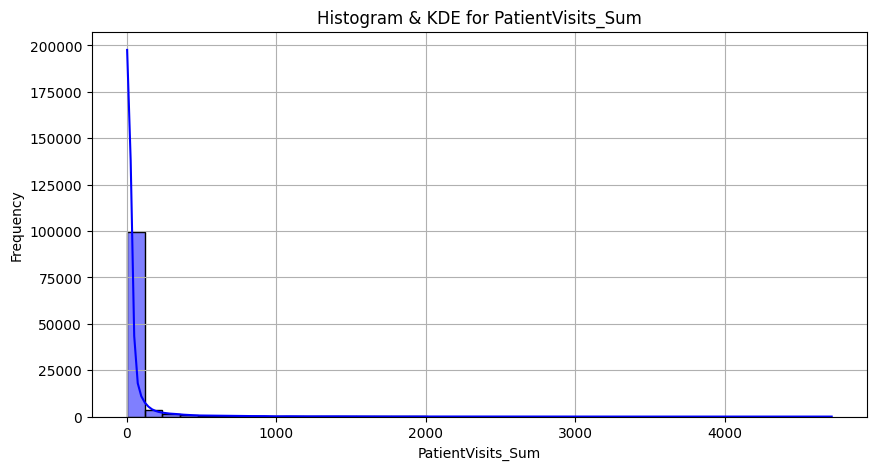

In [22]:
for col in numeric_cols:
    plt.figure(figsize=(10,5))
    sns.histplot(df[col].dropna(), kde=True, bins=40, color='blue')
    plt.title(f"Histogram & KDE for {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()


The data is NOT normal, not symmetric, not smooth.
Because 99% of data is between 1 and ~100, and only 0.1% go beyond that.
The extreme values stretch the X-axis so much that everything else becomes compressed.



In [23]:
stats_summary = []

for col in numeric_cols:
    s = df[col].dropna()
    stats_summary.append({
        "column": col,
        "mean": s.mean(),
        "median": s.median(),
        "mode": s.mode().iloc[0] if not s.mode().empty else np.nan,
        "variance": s.var(),
        "std_dev": s.std(),
        "skewness": s.skew(),
        "kurtosis": s.kurtosis()
    })

stats_df = pd.DataFrame(stats_summary)
print("\n Descriptive Statistics:")
display(stats_df)



 Descriptive Statistics:


,column,mean,median,mode,variance,std_dev,skewness,kurtosis
0,PatientVisits_Sum,51.352021,4.0,1,37710.554195,194.192055,8.587652,100.263843


In [24]:
outlier_report = []

for col in numeric_cols:
    s = df[col].dropna()

    z = (s - s.mean()) / s.std()
    z_outliers = (np.abs(z) > 3).sum()

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum()

    outlier_report.append({
        "column": col,
        "zscore_outliers": int(z_outliers),
        "iqr_outliers": int(iqr_outliers),
        "total_rows": len(s)
    })

outliers_df = pd.DataFrame(outlier_report)
print("\n Outlier Detection Summary:")
display(outliers_df)


 Outlier Detection Summary:


,column,zscore_outliers,iqr_outliers,total_rows
0,PatientVisits_Sum,1935,16066,108198


Z-score works only for normal-like data → your data is NOT normal → Z-score missed most outliers.
IQR works for skewed data → caught a LOT more outliers (correct).

They are not mistakes — they are high-utilization patients, a real healthcare pattern.
Don’t remove them blindly.

Instead:
transform
scale
or use tree-based models (which handle them well)

In [25]:

missing_summary = pd.DataFrame({
    "missing_count": df[numeric_cols].isna().sum(),
    "missing_percent": (df[numeric_cols].isna().mean() * 100).round(2)
})

print("\n Missing Value Summary:")
display(missing_summary)


 Missing Value Summary:


,missing_count,missing_percent
PatientVisits_Sum,0,0.0


In [26]:

cat_cols = [c for c in df.columns if df[c].dtype == "object"]
print("Categorical Columns:", cat_cols)

categorical_report = []


Categorical Columns: ['Category_Grouped', 'MonthYear', 'AgeGroup', 'Gender', 'CompanyName', 'DrugName', 'type']


ANALYSIS FOR COLUMN: Category_Grouped
Top Categories:


,count,percent
Category_Grouped,,
Primary Care,43530,40.23
Orthopedic,36620,33.85
Other,18209,16.83
Onco-Rheumatology,9839,9.09


/tmp/ipython-input-664598386.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_table.head(20).index, y=freq_table.head(20)["count"], palette="Blues_d")


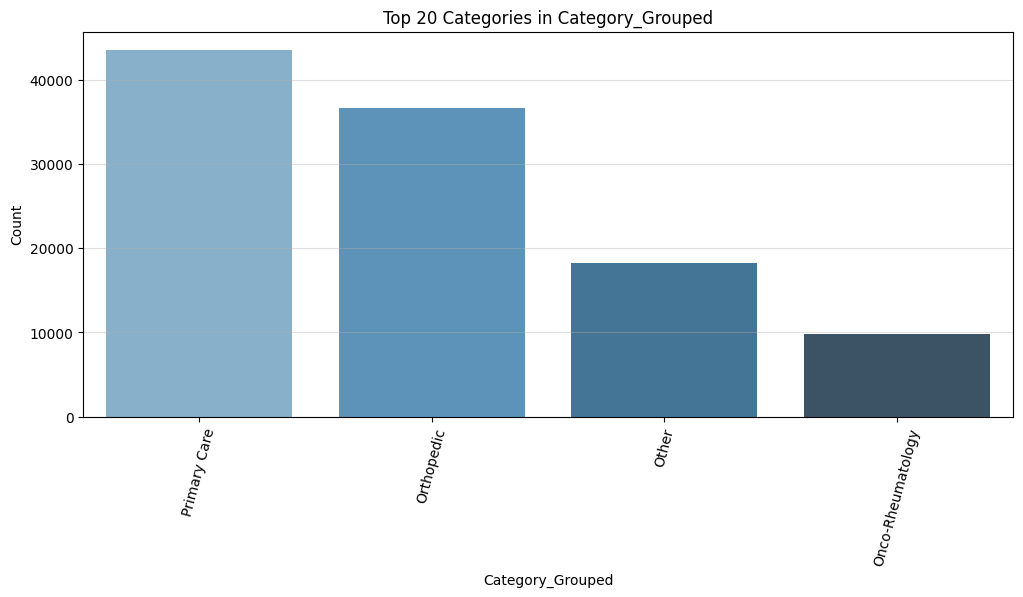

Cardinality (unique categories): 4

Categories < 5%:


,count,percent
Category_Grouped,,


Categories < 1%:


,count,percent
Category_Grouped,,


 Dominant category: 'Primary Care' with 40.23% share
 Moderate imbalance detected (dominant > 30%)
Entropy: 1.8046 bits
ANALYSIS FOR COLUMN: MonthYear
Top Categories:


,count,percent
MonthYear,,
March 2023,1725,1.59
October 2022,1712,1.58
January 2024,1711,1.58
August 2023,1706,1.58
October 2023,1693,1.56
August 2022,1685,1.56
November 2023,1678,1.55
May 2023,1678,1.55
March 2022,1674,1.55


/tmp/ipython-input-664598386.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_table.head(20).index, y=freq_table.head(20)["count"], palette="Blues_d")


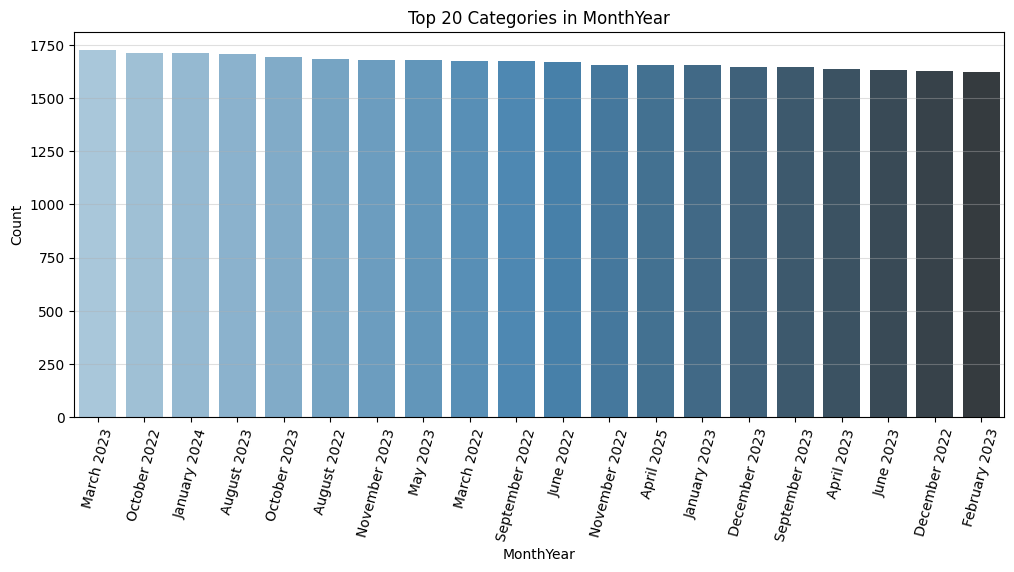

Cardinality (unique categories): 72

Categories < 5%:


,count,percent
MonthYear,,
March 2023,1725,1.59
October 2022,1712,1.58
January 2024,1711,1.58
August 2023,1706,1.58
October 2023,1693,1.56
...,...,...
November 2019,1239,1.15
September 2019,1231,1.14
May 2020,1212,1.12


Categories < 1%:


,count,percent
MonthYear,,
April 2020,989,0.91


 Dominant category: 'March 2023' with 1.59% share
 No major imbalance
Entropy: 6.1612 bits
ANALYSIS FOR COLUMN: AgeGroup
Top Categories:


,count,percent
AgeGroup,,
65 To 74,22914,21.18
40 To 59,22039,20.37
60 To 64,19030,17.59
75 To 84,18102,16.73
85 +,16734,15.47
Below 40,9379,8.67


/tmp/ipython-input-664598386.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_table.head(20).index, y=freq_table.head(20)["count"], palette="Blues_d")


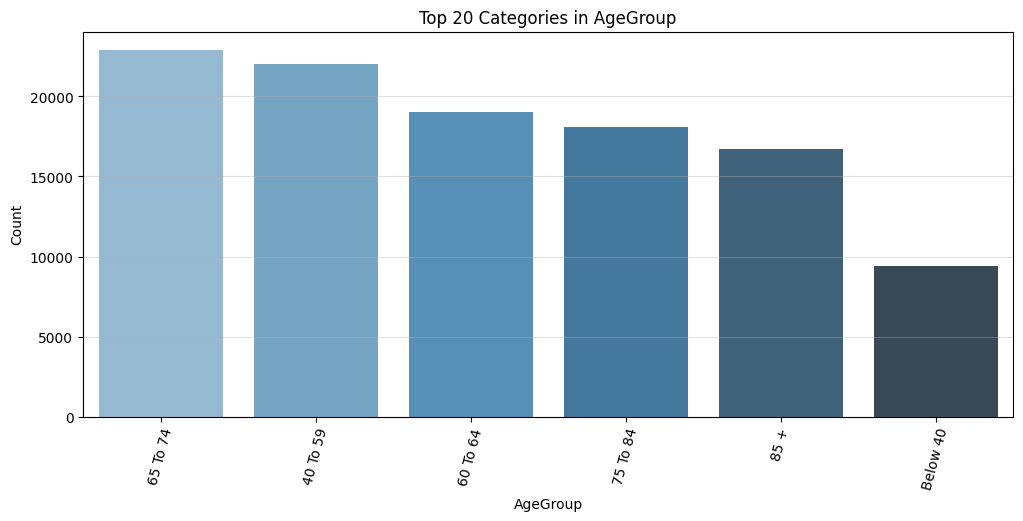

Cardinality (unique categories): 6

Categories < 5%:


,count,percent
AgeGroup,,


Categories < 1%:


,count,percent
AgeGroup,,


 Dominant category: '65 To 74' with 21.18% share
 No major imbalance
Entropy: 2.5368 bits
ANALYSIS FOR COLUMN: Gender
Top Categories:


,count,percent
Gender,,
Female,59073,54.60
Male,48610,44.93
Unspecified,515,0.48


/tmp/ipython-input-664598386.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_table.head(20).index, y=freq_table.head(20)["count"], palette="Blues_d")


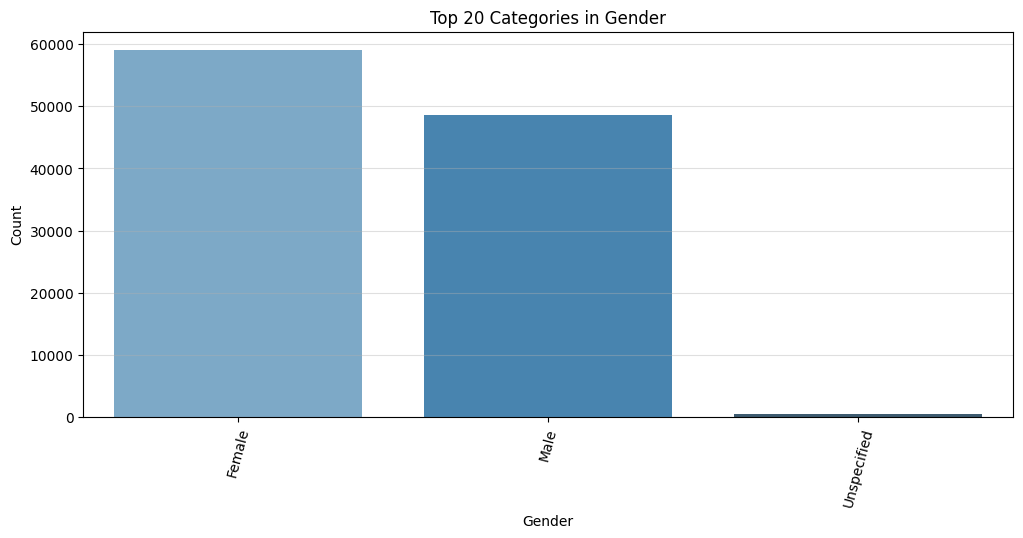

Cardinality (unique categories): 3

Categories < 5%:


,count,percent
Gender,,
Unspecified,515,0.48


Categories < 1%:


,count,percent
Gender,,
Unspecified,515,0.48


 Dominant category: 'Female' with 54.6% share
 Severe imbalance detected (dominant > 50%)
Entropy: 1.0323 bits
ANALYSIS FOR COLUMN: CompanyName
Top Categories:


,count,percent
CompanyName,,
Pfizer,9784,9.04
Major Pharm,7644,7.06
Amneal Biosciences,5649,5.22
Fresenius Kabi Usa,5564,5.14
Teva Parenteral Me,5513,5.10
Private Label,4338,4.01
Northstar Rx,3611,3.34
Bristol-M Sq Us Ph,3600,3.33
Time-Cap Labs,3494,3.23


/tmp/ipython-input-664598386.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_table.head(20).index, y=freq_table.head(20)["count"], palette="Blues_d")


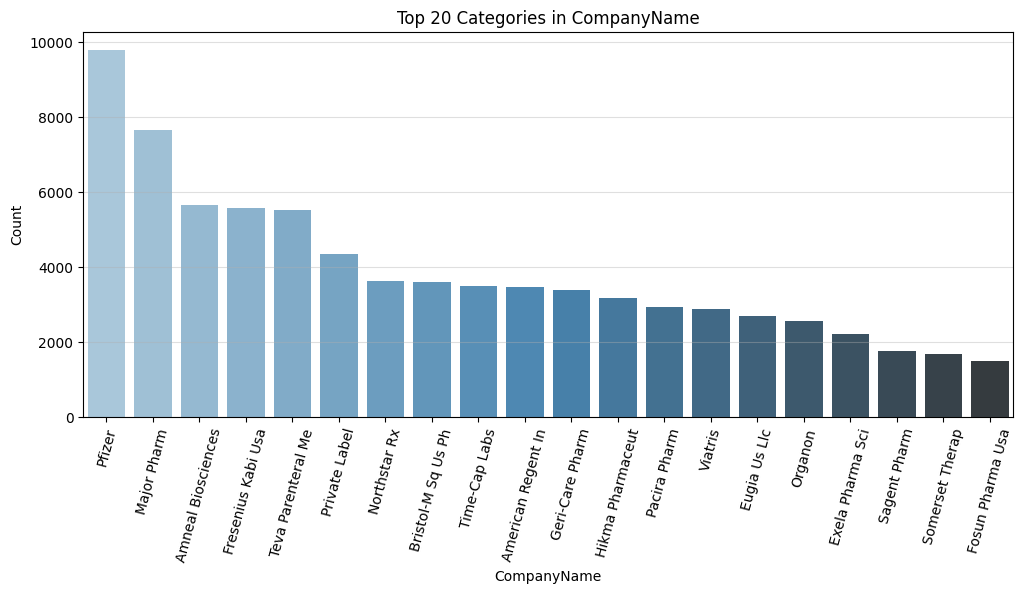

Cardinality (unique categories): 166

Categories < 5%:


,count,percent
CompanyName,,
Private Label,4338,4.01
Northstar Rx,3611,3.34
Bristol-M Sq Us Ph,3600,3.33
Time-Cap Labs,3494,3.23
American Regent In,3469,3.21
...,...,...
Camber Consumer Ca,1,0.00
Bionpharma Inc.,1,0.00
Generamed Inc,1,0.00


Categories < 1%:


,count,percent
CompanyName,,
Akron Pharma,1061,0.98
Almaject Inc,1035,0.96
Bayer Consumer Car,846,0.78
Baxter I.V Sys Div,832,0.77
"Method Pharma, Llc",823,0.76
...,...,...
Camber Consumer Ca,1,0.00
Bionpharma Inc.,1,0.00
Generamed Inc,1,0.00


 Dominant category: 'Pfizer' with 9.04% share
 No major imbalance
Entropy: 5.3999 bits
ANALYSIS FOR COLUMN: DrugName
Top Categories:


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,count,percent
DrugName,,
Ketorolac Trometh,11660,10.78
Methylpred Ace,10934,10.11
Acetaminophen,10293,9.51
Triamcinolone Actn,10140,9.37
Aspirin,9870,9.12
Dexameth S Ph,9400,8.69
Betameth Ace/Sod Phos,5190,4.80
Zilretta,4634,4.28
Diclofenac Pot,4273,3.95


/tmp/ipython-input-664598386.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_table.head(20).index, y=freq_table.head(20)["count"], palette="Blues_d")


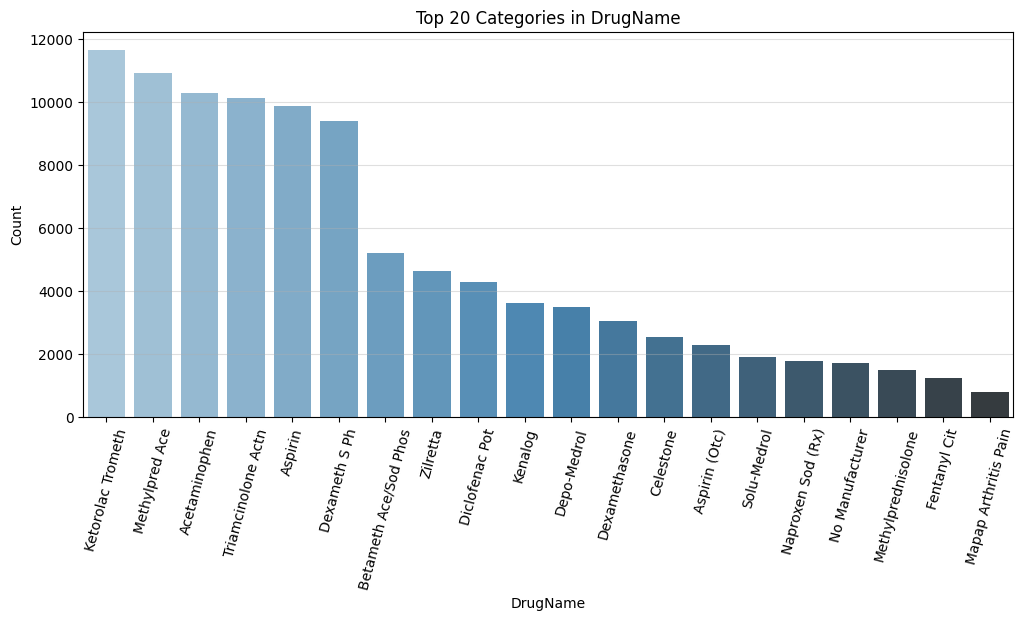

Cardinality (unique categories): 145

Categories < 5%:


,count,percent
DrugName,,
Betameth Ace/Sod Phos,5190,4.80
Zilretta,4634,4.28
Diclofenac Pot,4273,3.95
Kenalog,3600,3.33
Depo-Medrol,3497,3.23
...,...,...
Childrens Mapap,1,0.00
Baycadron,1,0.00
Apap/Caf,1,0.00


Categories < 1%:


,count,percent
DrugName,,
Mapap Arthritis Pain,788,0.73
Bayer Asp Regimen,589,0.54
Methylpred Sod Suc,550,0.51
Ibuprofen (Otc),376,0.35
Phys Ez Use Joint,365,0.34
...,...,...
Childrens Mapap,1,0.00
Baycadron,1,0.00
Apap/Caf,1,0.00


 Dominant category: 'Ketorolac Trometh' with 10.78% share
 No major imbalance
Entropy: 4.4206 bits
ANALYSIS FOR COLUMN: type
Top Categories:


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,count,percent
type,,
Generic,56022,51.78
Brand,24742,22.87
Other,18992,17.55
Branded Generic,8442,7.80


/tmp/ipython-input-664598386.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_table.head(20).index, y=freq_table.head(20)["count"], palette="Blues_d")


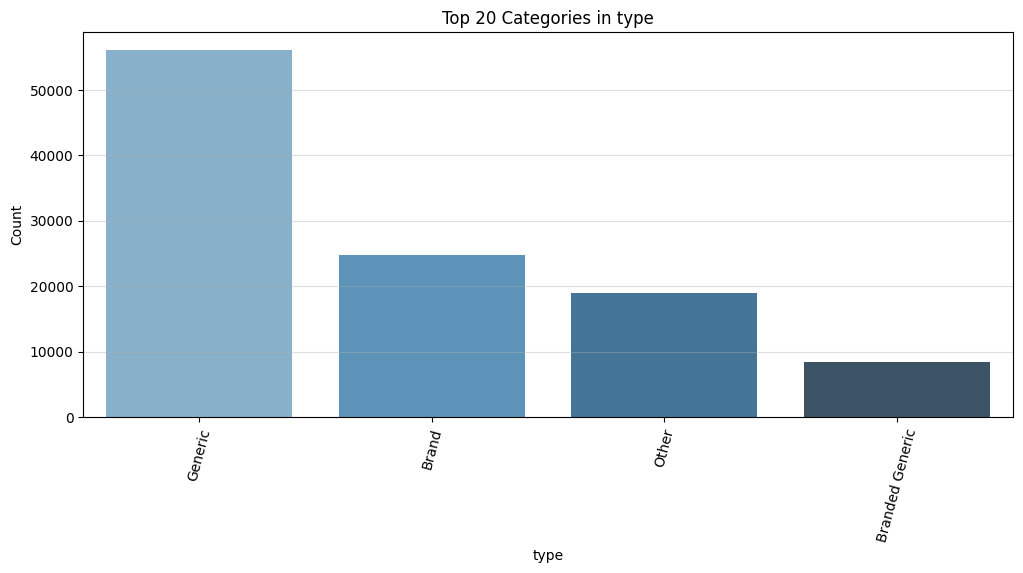

Cardinality (unique categories): 4

Categories < 5%:


,count,percent
type,,


Categories < 1%:


,count,percent
type,,


 Dominant category: 'Generic' with 51.78% share
 Severe imbalance detected (dominant > 50%)
Entropy: 1.7061 bits


In [27]:
for col in cat_cols:

    print(f"ANALYSIS FOR COLUMN: {col}")

    s = df[col].astype(str)

    counts = s.value_counts(dropna=False)
    pct = (counts / len(s) * 100).round(2)

    freq_table = pd.DataFrame({"count": counts, "percent": pct})
    print("Top Categories:")
    display(freq_table.head(20))


    plt.figure(figsize=(12,5))
    sns.barplot(x=freq_table.head(20).index, y=freq_table.head(20)["count"], palette="Blues_d")
    plt.xticks(rotation=75)
    plt.title(f"Top 20 Categories in {col}")
    plt.ylabel("Count")
    plt.grid(axis='y', alpha=0.4)
    plt.show()

    cardinality = s.nunique()
    print(f"Cardinality (unique categories): {cardinality}")

    rare_5 = freq_table[freq_table["percent"] < 5]
    rare_1 = freq_table[freq_table["percent"] < 1]

    print("\nCategories < 5%:")
    display(rare_5)

    print("Categories < 1%:")
    display(rare_1)

    # IMBALANCE CHECK (dominance)
    dominant = pct.max()
    dominant_category = pct.idxmax()

    print(f" Dominant category: '{dominant_category}' with {dominant}% share")

    if dominant > 50:
        print(" Severe imbalance detected (dominant > 50%)")
    elif dominant > 30:
        print(" Moderate imbalance detected (dominant > 30%)")
    else:
        print(" No major imbalance")

    probs = pct / 100
    entropy = -(probs * np.log2(probs)).sum()

    print(f"Entropy: {entropy:.4f} bits")
    categorical_report.append({
        "column": col,
        "cardinality": cardinality,
        "dominant_category": dominant_category,
        "dominant_percent": dominant,
        "entropy": entropy,
        "rare_categories_<5%": len(rare_5),
        "rare_categories_<1%": len(rare_1)
    })


1. Category_Grouped: Primary Care 40.23% dominates , Orthopedic is Strong and followed by Others and Entropy is 1.80 bits defining that few categories hold most of the mass. It is having moderate skew, but use stratified splits if category_grouped in the target or key segment. If adding as feature no need to rebalance, but used as target consider class weights or macro metrics to avoid bias.

2. Month Year: Has 72 unique months, entropy has 6.16 bits (high, for many almost-equal bins) and it is have great coverage for time modelling and low risk of leakage and is very ideal for time-series splits like train on earlier months and validate on later.
Extract the Year,month, Quarter,and Time Index, for forecasting keep chronologival train/val/test splits.

3. Age Group: Entropy is 2.54 bits whihc is decently distributed.
Balanced enough for strtification no rebalancing needed. Good efffects with interaction effects with Category_Grouped,Gender, DrugName. Consider ordering (ordinal encoding )if modelling assumes order.

4. Gender: Entropy 1.03 bits low (beacuse one class dominates and one is tiny)
Severe imbalance threshold corssed(>50%) and unspecified is tiny where models can overfit it ftreates as full class.
Feature Use: Keep all three and consider target encoding and let the model learn.
If Gender is the target, use class weights or resamplimg.

5. CompanyName: Head is diversified where Pfizer is top share, but most companies are rare(<1% many, long tail). Entropy 5.40 bits -high but with a heavy tail. Classic high-cardinality problem so dont go with one-hot as it creates many near-empty columns and harming the generalization.
Use grequency encoding or target mean encoding with K-fold smoothing to avoid leakage.
Optional Step : Group rare compnaies into Other for reporting but for modeling prefer encodings above.

6. DrugName: Multiple drugs in 9-11% range, then a long tail of rares(<1%). Entropy is 4.42 bits (diverse, long tail)
High-cardinalty challenge. Prefer frequency/target encoding or hashing for linear models.
Consider buikding therapeutic class features (map drug ->class) to reduce cardinality with domain signal.

7.Type: Generic dominates (51.78%) Entropy 1.71 bits, severe imbalance due to Generic. If type is feature imbalance is fine and it becomes the target use class weights and macro metrics.


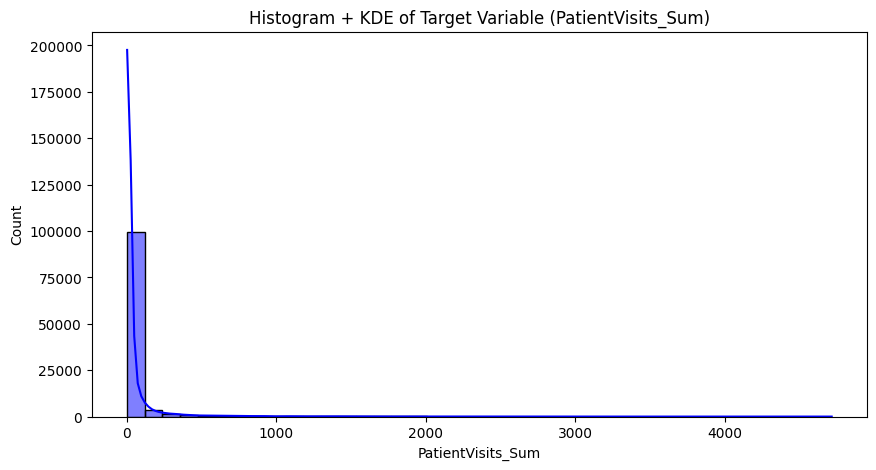

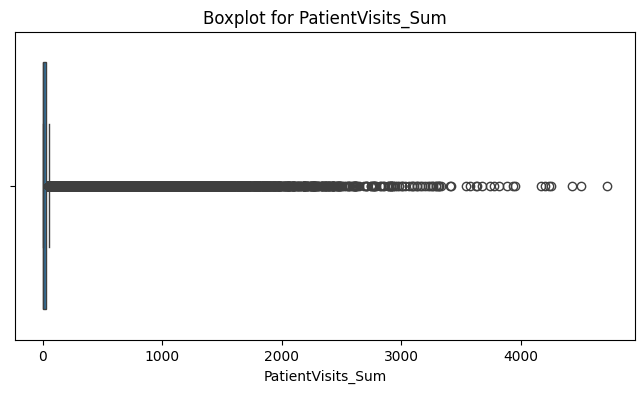


Target Variable Basic Stats:


,PatientVisits_Sum
count,108198.000000
mean,51.352021
std,194.192055
min,1.000000
25%,1.000000
50%,4.000000
75%,22.000000
max,4717.000000



Skewness: 8.587652020793044
Kurtosis: 100.26384307824692


/tmp/ipython-input-3386436941.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["MonthYear_dt"] = pd.to_datetime(df["MonthYear"])


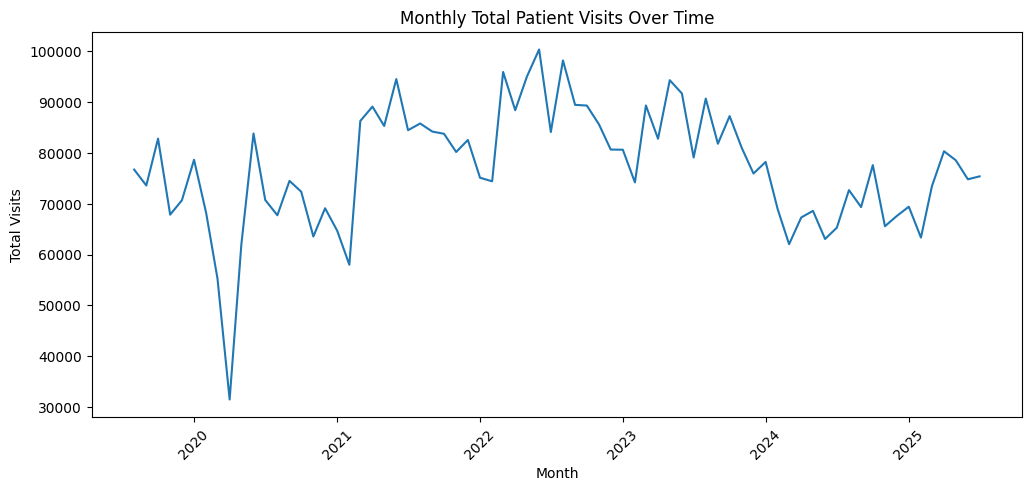

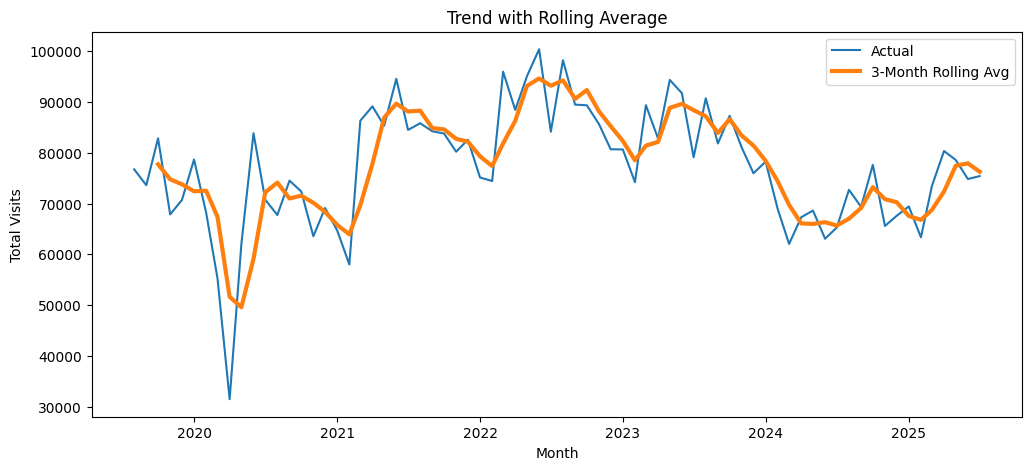

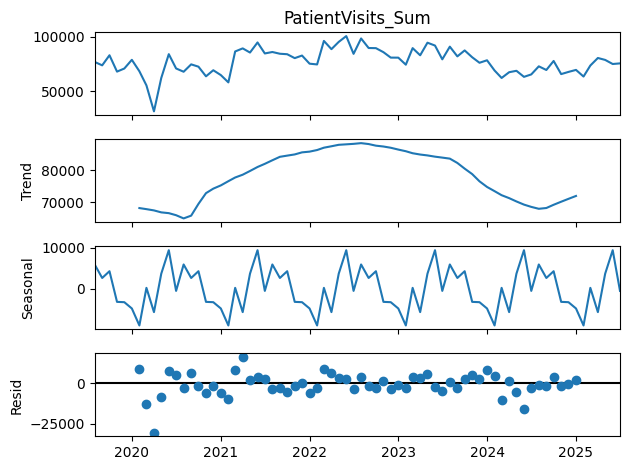

In [28]:
target = "PatientVisits_Sum"

plt.figure(figsize=(10,5))
sns.histplot(df[target], kde=True, bins=40, color='blue')
plt.title("Histogram + KDE of Target Variable (PatientVisits_Sum)")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df[target])
plt.title("Boxplot for PatientVisits_Sum")
plt.show()

print("\nTarget Variable Basic Stats:")
display(df[target].describe())

print("\nSkewness:", df[target].skew())
print("Kurtosis:", df[target].kurtosis())

df["MonthYear_dt"] = pd.to_datetime(df["MonthYear"])

monthly = df.groupby("MonthYear_dt")[target].sum().sort_index()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values)
plt.title("Monthly Total Patient Visits Over Time")
plt.xlabel("Month")
plt.ylabel("Total Visits")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, label="Actual")
plt.plot(monthly.index, monthly.rolling(3).mean(), label="3-Month Rolling Avg", linewidth=3)
plt.legend()
plt.title("Trend with Rolling Average")
plt.xlabel("Month")
plt.ylabel("Total Visits")
plt.show()

decomp = seasonal_decompose(monthly, model='additive', period=12)
decomp.plot()
plt.show()

Histogram+KDE Tells about the extreme right skewed distribution

Boxplottells that there are many outliers where 50% of patients have 4 or fewer visits as some have 500,1000,2000,4000+visists outliers tells the real extreme behaviour and healthcare datasets follow "power-law behaviour" and also defining that few individuals consume a huge amout of resources. Z-Score is not prefect for skewed data and IQR Outlier Detection works better for skewed data.

Going with the skewness 0 is perfectly symmetrical, 1 is moderately skewed, 2 is strongly skewed, a skewness above 2 means some log transofrmation is recommended.
Should go with Log Transformation, Robust Scaling, Winsorization.

Kurtosis defines the data distribution, describing the degree to which data points are outliers compared to a normal distribution.
Normal distribution follows around 3 but out data has 100 defining heavy tail distribution defining the extreme values dominate the dataset, Variance is not stable.

The line plot tells the trends like this
The line plot shows:
Sharp dips (COVID shock around 2020)
A recovery wave in 2021
Peak volumes in 2021–2022
A slow decline or stabilization in 2023–2024
A slight uptick again near 2025

Rolling Average : shows the same results more like and has a meaningful structure, time-series modeling(Prphet, ARIMA ,LSTM , SARIMA, Seasonal Decompostition, Markov Models) is valid and seasonlaity is strong and stable.


Trend: Tells that Increases until 2022 and declines slowly afterward, tells about the real-world clinical behaviour (spike and stabilization)

Seasonal Component: Good month oscillations, very helpful for forecasting

Residuals:They define what are left with trends and seasonlaities, They represent the random noise or unpredictable variation in the data that the trend and seasonality components couldn't explain and here in this residuals are mostly centered around zero and big differences( around pandemic) and the decomposition is valid.

Stability of Target Varibale : Helps to check the target behaves consistently over time and across groups, telling whether it drifts, shifts,or changes patterns. Important for predicitve modeling,forecasting,fairness analysis,feature engineering, understanding the real-world behaviour

Rows after target cleaning: 108,198


/tmp/ipython-input-3896919856.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["MonthYear_dt"] = pd.to_datetime(df["MonthYear"], errors="coerce")


,MonthStart,total,mean,median,n,pct_change_total,rolling_total
0,2019-08-01,76737,59.857254,4.0,1282,NaN,76737.000000
1,2019-09-01,73610,59.796913,4.0,1231,-0.040750,75173.500000
2,2019-10-01,82836,63.671022,4.0,1301,0.125336,77727.666667
3,2019-11-01,67868,54.776433,4.0,1239,-0.180694,74771.333333
4,2019-12-01,70695,55.534171,4.0,1273,0.041654,73799.666667
5,2020-01-01,78673,60.939582,4.0,1291,0.112851,72412.000000
6,2020-02-01,68195,53.994458,4.0,1263,-0.133184,72521.000000
7,2020-03-01,55250,46.003331,4.0,1201,-0.189823,67372.666667
8,2020-04-01,31479,31.829120,3.0,989,-0.430244,51641.333333
9,2020-05-01,62034,51.183168,4.0,1212,0.970647,49587.666667



 Potential monthly spikes (>|25%| change):


,MonthStart,total,pct_change_total
8,2020-04-01,31479,-0.430244
9,2020-05-01,62034,0.970647
10,2020-06-01,83844,0.351581
19,2021-03-01,86313,0.487976
31,2022-03-01,95963,0.289236


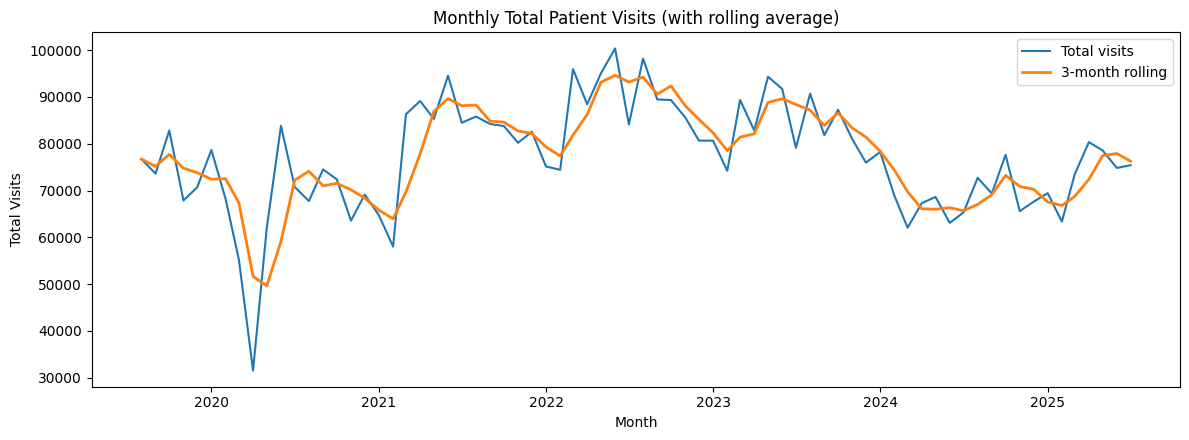

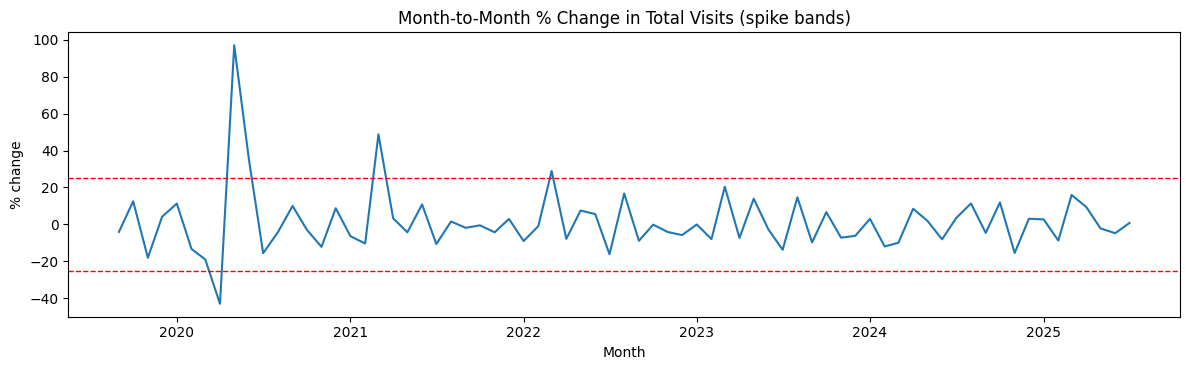


 Column: Category_Grouped


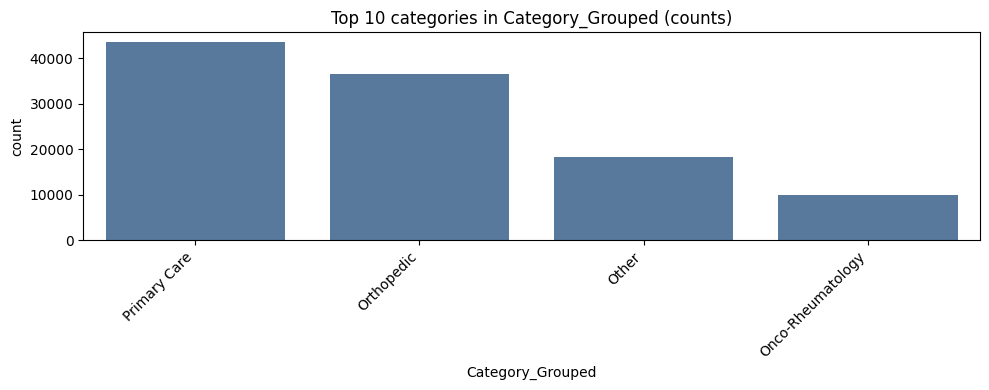

,count,percent
Category_Grouped,,
Primary Care,43530,40.23
Orthopedic,36620,33.85
Other,18209,16.83
Onco-Rheumatology,9839,9.09


,total,mean,median,n
Category_Grouped,,,,
Orthopedic,3031458,82.781486,7.0,36620
Primary Care,2288296,52.568252,6.0,43530
Other,132650,7.284859,2.0,18209
Onco-Rheumatology,103782,10.548023,2.0,9839


Volatility of monthly share (std): top 10


,share_std
Category_Grouped,
Primary Care,0.058758
Orthopedic,0.051560
Onco-Rheumatology,0.005016
Other,0.002978


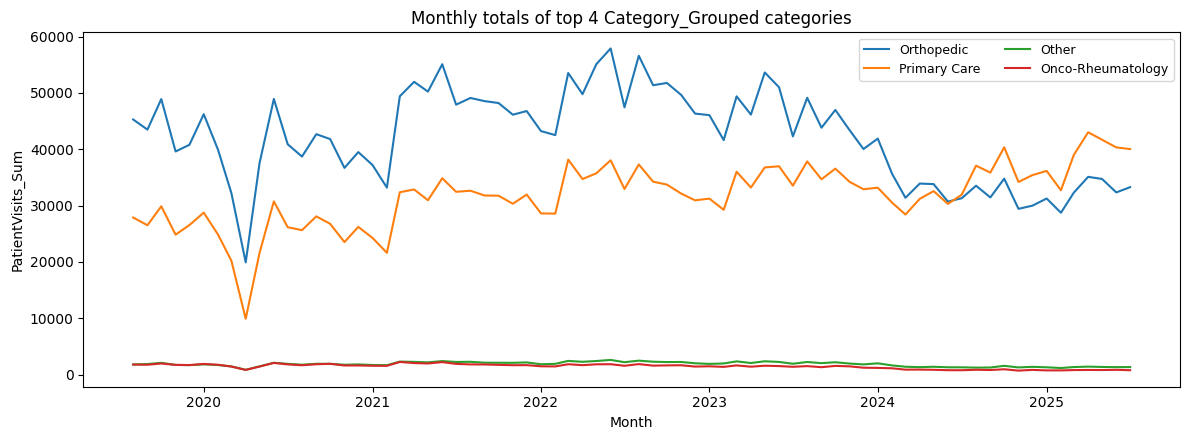


 Column: MonthYear


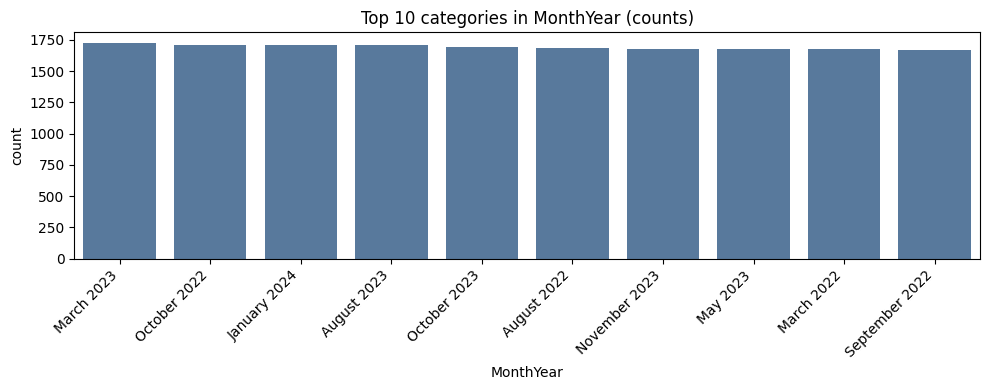

,count,percent
MonthYear,,
March 2023,1725,1.59
October 2022,1712,1.58
January 2024,1711,1.58
August 2023,1706,1.58
October 2023,1693,1.56
August 2022,1685,1.56
November 2023,1678,1.55
May 2023,1678,1.55
March 2022,1674,1.55


,total,mean,median,n
MonthYear,,,,
June 2022,100385,60.146794,5.0,1669
August 2022,98224,58.293175,5.0,1685
March 2022,95963,57.325568,4.0,1674
May 2022,95073,58.905204,4.0,1614
June 2021,94560,63.082055,4.0,1499
May 2023,94340,56.221692,5.0,1678
June 2023,91732,56.242796,5.0,1631
August 2023,90718,53.175850,4.0,1706
September 2022,89481,53.485356,5.0,1673


Volatility of monthly share (std): top 10


,share_std
MonthYear,
April 2020,NaN
April 2021,NaN
April 2022,NaN
April 2023,NaN
April 2024,NaN
April 2025,NaN
August 2019,NaN
August 2020,NaN
August 2021,NaN


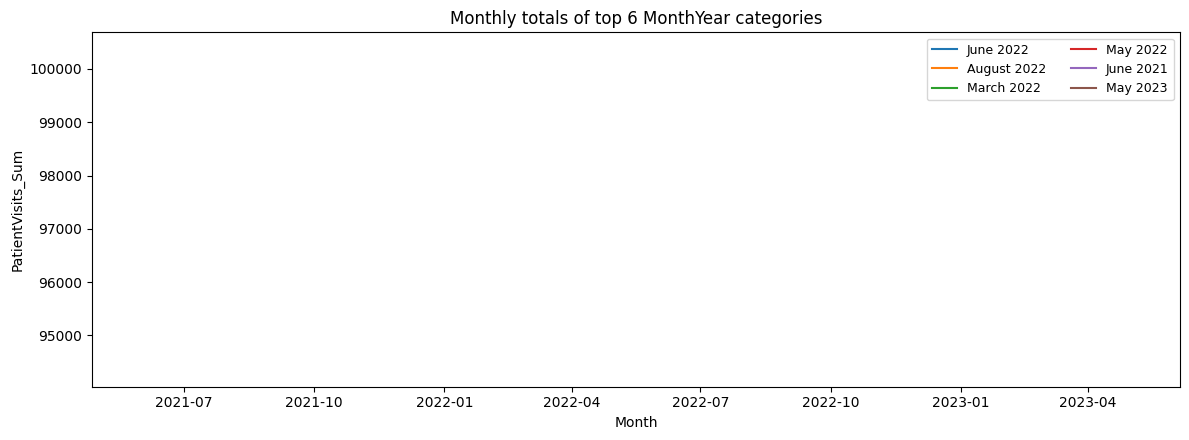


 Column: AgeGroup


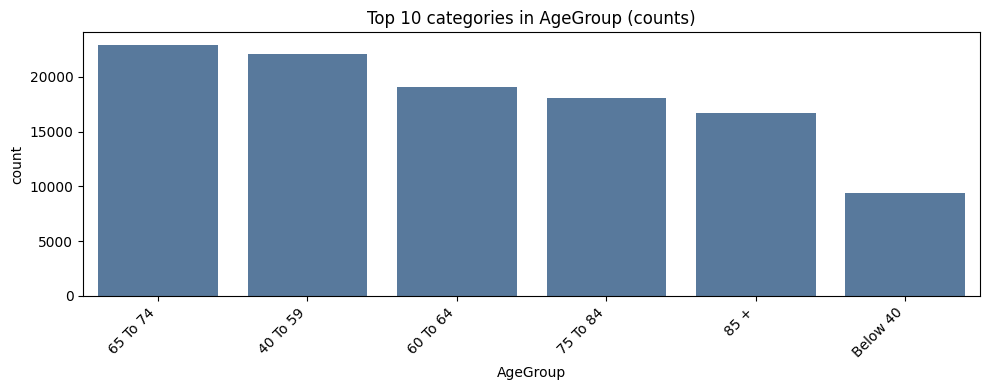

,count,percent
AgeGroup,,
65 To 74,22914,21.18
40 To 59,22039,20.37
60 To 64,19030,17.59
75 To 84,18102,16.73
85 +,16734,15.47
Below 40,9379,8.67


,total,mean,median,n
AgeGroup,,,,
65 To 74,1803152,78.692153,6.0,22914
40 To 59,1257371,57.052089,5.0,22039
75 To 84,926058,51.157773,6.0,18102
60 To 64,783033,41.147294,4.0,19030
85 +,713479,42.636489,5.0,16734
Below 40,73093,7.793262,2.0,9379


Volatility of monthly share (std): top 10


,share_std
AgeGroup,
75 To 84,0.042451
85 +,0.028592
40 To 59,0.016667
65 To 74,0.005865
60 To 64,0.004958
Below 40,0.001635


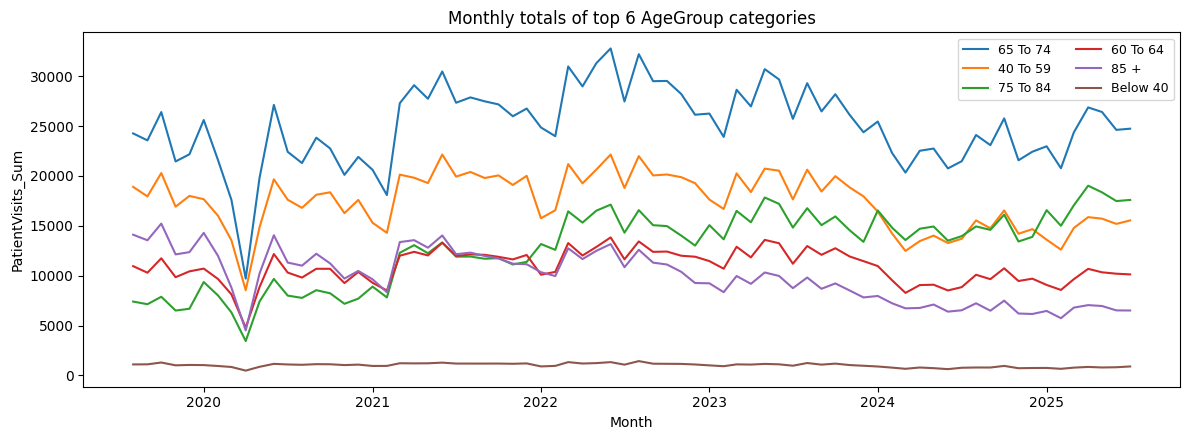


 Column: Gender


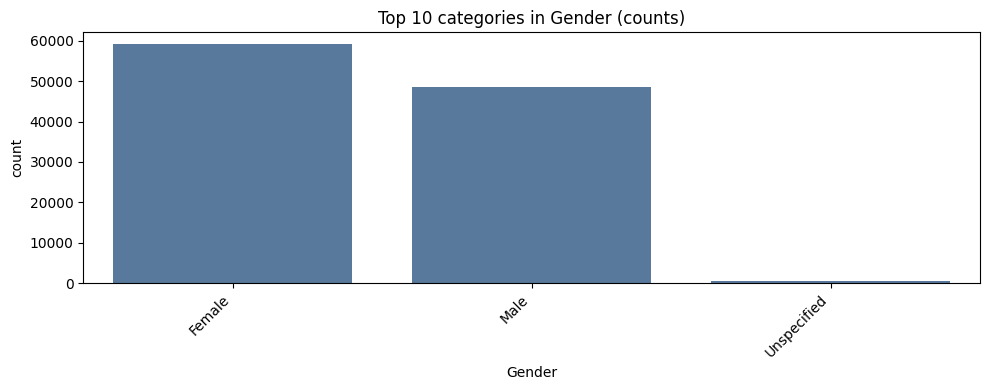

,count,percent
Gender,,
Female,59073,54.60
Male,48610,44.93
Unspecified,515,0.48


,total,mean,median,n
Gender,,,,
Female,3598112,60.909586,5.0,59073
Male,1957453,40.268525,4.0,48610
Unspecified,621,1.205825,1.0,515


Volatility of monthly share (std): top 10


,share_std
Gender,
Male,0.007296
Female,0.007289
Unspecified,0.000082


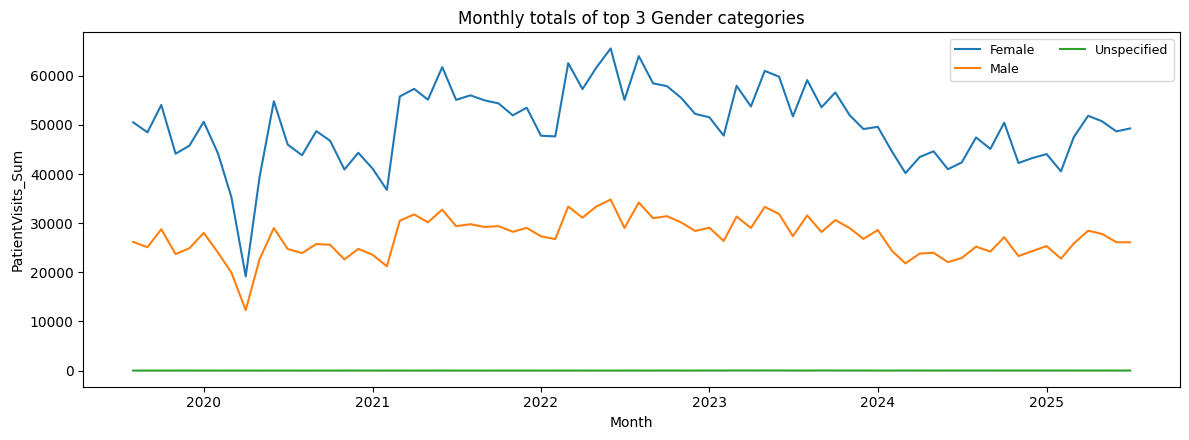


 Column: CompanyName


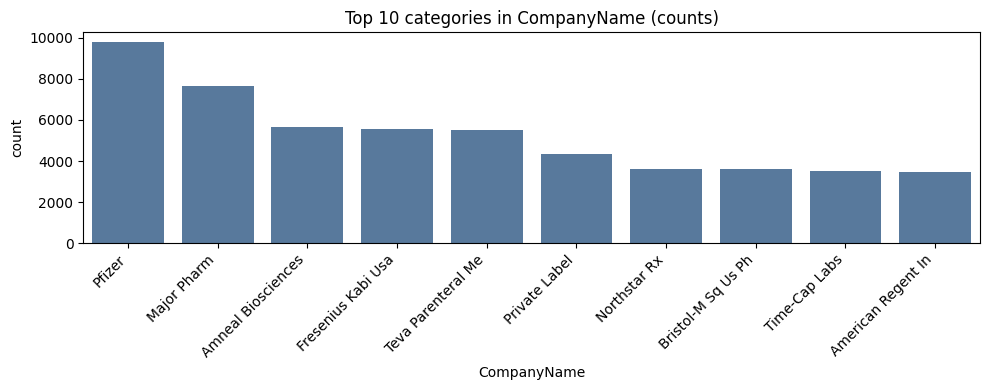

,count,percent
CompanyName,,
Pfizer,9784,9.04
Major Pharm,7644,7.06
Amneal Biosciences,5649,5.22
Fresenius Kabi Usa,5564,5.14
Teva Parenteral Me,5513,5.10
Private Label,4338,4.01
Northstar Rx,3611,3.34
Bristol-M Sq Us Ph,3600,3.33
Time-Cap Labs,3494,3.23


,total,mean,median,n
CompanyName,,,,
Bristol-M Sq Us Ph,1775124,493.090000,72.0,3600
Pfizer,1168506,119.430294,10.0,9784
Amneal Biosciences,600777,106.351036,18.0,5649
American Regent In,363436,104.766792,13.0,3469
Teva Parenteral Me,302399,54.851986,15.0,5513
Northstar Rx,220646,61.103849,8.0,3611
Fresenius Kabi Usa,185154,33.277139,7.0,5564
Major Pharm,184368,24.119309,4.0,7644
Pacira Pharm,123715,42.281271,12.0,2926


Volatility of monthly share (std): top 10


,share_std
CompanyName,
Pfizer,0.069655
Amneal Biosciences,0.031076
Northstar Rx,0.027541
Teva Parenteral Me,0.025230
Bristol-M Sq Us Ph,0.022229
Long Grove Pharma,0.015089
Organon,0.007624
Major Pharm,0.007294
Time-Cap Labs,0.006938


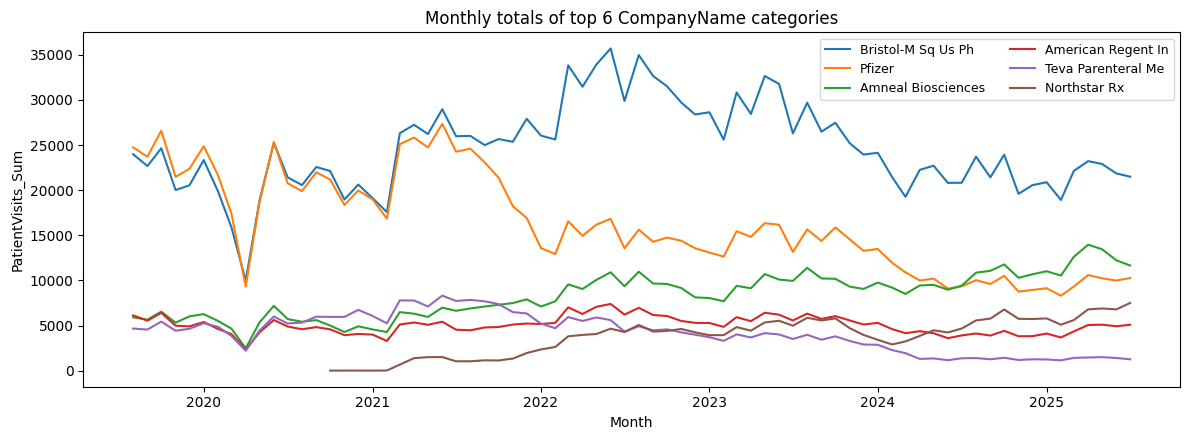


 Column: DrugName


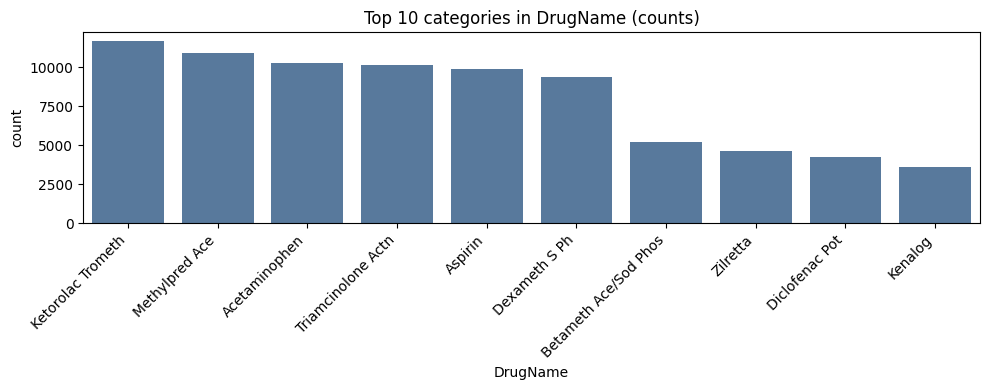

,count,percent
DrugName,,
Ketorolac Trometh,11660,10.78
Methylpred Ace,10934,10.11
Acetaminophen,10293,9.51
Triamcinolone Actn,10140,9.37
Aspirin,9870,9.12
Dexameth S Ph,9400,8.69
Betameth Ace/Sod Phos,5190,4.80
Zilretta,4634,4.28
Diclofenac Pot,4273,3.95


,total,mean,median,n
DrugName,,,,
Kenalog,1775124,493.090000,72.0,3600
Depo-Medrol,1102905,315.386045,79.0,3497
Triamcinolone Actn,834657,82.313314,14.0,10140
Betameth Ace/Sod Phos,399299,76.936224,13.0,5190
Methylpred Ace,390839,35.745290,8.0,10934
Dexamethasone,166757,54.620701,21.0,3053
Aspirin,151673,15.367072,4.0,9870
Zilretta,135118,29.157963,7.0,4634
Acetaminophen,129477,12.579131,3.0,10293


Volatility of monthly share (std): top 10


,share_std
DrugName,
Depo-Medrol,0.068563
Triamcinolone Actn,0.060894
Kenalog,0.022229
Celestone,0.007624
Methylpred Ace,0.007179
Acetaminophen,0.006912
Betameth Ace/Sod Phos,0.006790
Aspirin,0.004385
Aspirin (Otc),0.004299


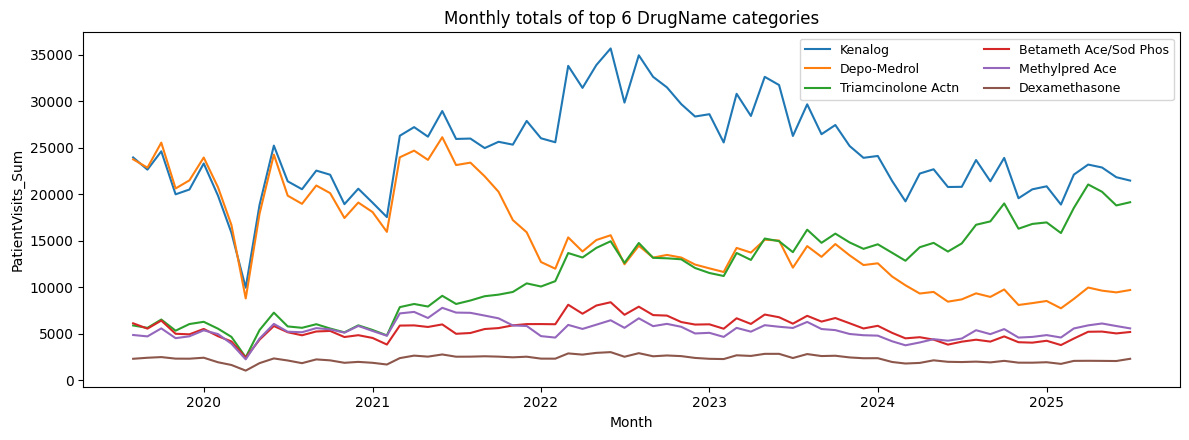


 Column: type


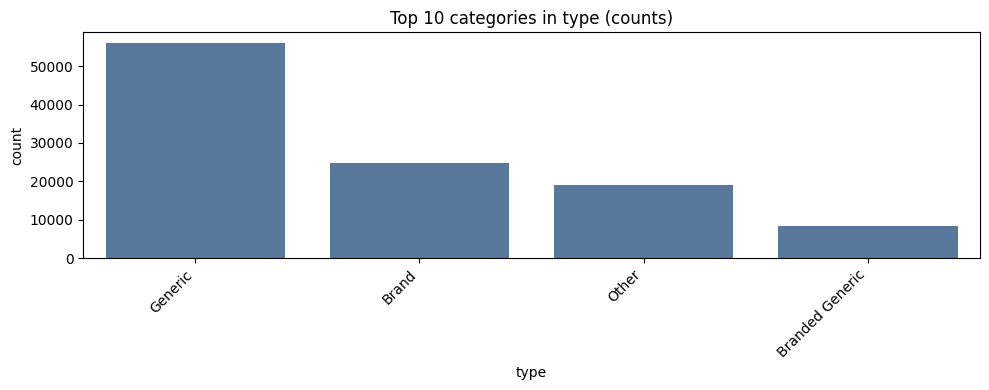

,count,percent
type,,
Generic,56022,51.78
Brand,24742,22.87
Other,18992,17.55
Branded Generic,8442,7.80


,total,mean,median,n
type,,,,
Generic,2022577,36.103263,5.0,56022
Branded Generic,1903357,225.462805,19.0,8442
Brand,1492083,60.305675,5.0,24742
Other,138169,7.275116,2.0,18992


Volatility of monthly share (std): top 10


,share_std
type,
Brand,0.072945
Generic,0.059897
Branded Generic,0.024703
Other,0.008922


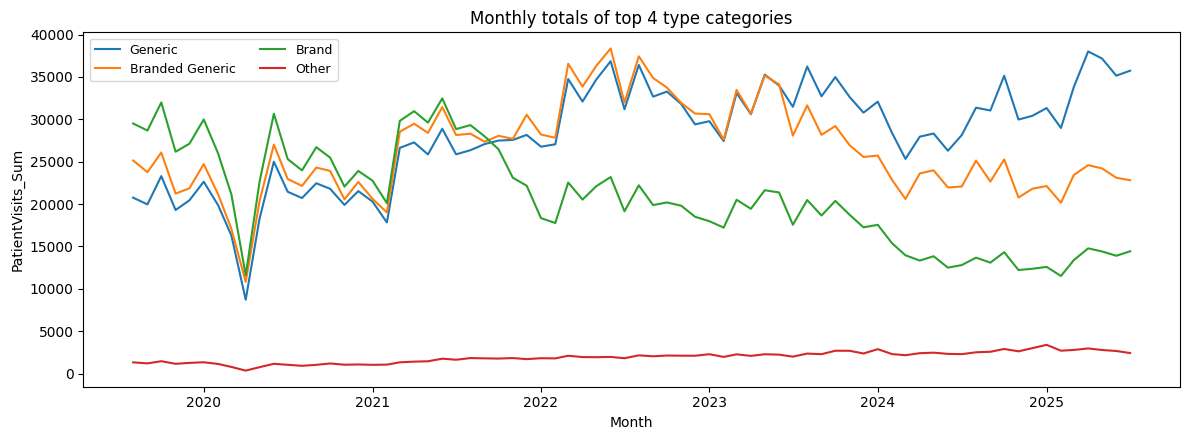

In [29]:
TARGET_COL = "PatientVisits_Sum"
CAT_COLS = ["Category_Grouped", "MonthYear", "AgeGroup", "Gender",
            "CompanyName", "DrugName", "type"]
TOP_K = 10
TOP_K_LINES = 6
ROLL_WINDOW = 3
SPIKE_PCT = 0.25


df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")


if "type" in df.columns:
    df["type"] = (df["type"]
                  .astype(str)
                  .str.strip()
                  .str.title()
                  .replace({"Others": "Other"}))


if "MonthYear" in df.columns:
    df["MonthYear_dt"] = pd.to_datetime(df["MonthYear"], errors="coerce")

    df["MonthStart"] = df["MonthYear_dt"].dt.to_period("M").dt.to_timestamp()
else:

    df["MonthStart"] = pd.NaT

df = df[~df[TARGET_COL].isna()].copy()

print(f"Rows after target cleaning: {len(df):,}")


if df["MonthStart"].notna().any():
    monthly = (df.groupby("MonthStart", as_index=False)[TARGET_COL]
                 .agg(total="sum", mean="mean", median="median", n="count"))
    monthly["pct_change_total"] = monthly["total"].pct_change()
    monthly["rolling_total"] = monthly["total"].rolling(ROLL_WINDOW, min_periods=1).mean()
    spikes = monthly.loc[monthly["pct_change_total"].abs() > SPIKE_PCT,
                         ["MonthStart", "total", "pct_change_total"]]

    display(monthly.head(12))
    print("\n Potential monthly spikes (>|25%| change):")
    display(spikes)


    plt.figure(figsize=(12,4.5))
    plt.plot(monthly["MonthStart"], monthly["total"], label="Total visits")
    plt.plot(monthly["MonthStart"], monthly["rolling_total"],
             label=f"{ROLL_WINDOW}-month rolling", linewidth=2)
    plt.title("Monthly Total Patient Visits (with rolling average)")
    plt.xlabel("Month"); plt.ylabel("Total Visits"); plt.legend(); plt.tight_layout(); plt.show()


    plt.figure(figsize=(12,3.8))
    plt.plot(monthly["MonthStart"], monthly["pct_change_total"]*100)
    plt.axhline(SPIKE_PCT*100, color="r", linestyle="--", linewidth=1)
    plt.axhline(-SPIKE_PCT*100, color="r", linestyle="--", linewidth=1)
    plt.title("Month-to-Month % Change in Total Visits (spike bands)")
    plt.xlabel("Month"); plt.ylabel("% change"); plt.tight_layout(); plt.show()


def top_categories(df, col, k=TOP_K):
    freq = (df[col].astype(str)
              .value_counts(dropna=False)
              .rename("count")
              .to_frame())
    freq["percent"] = (freq["count"] / len(df) * 100).round(2)
    return freq.head(k)

def category_summary(df, col):

    agg = (df.groupby(col, dropna=False)[TARGET_COL]
             .agg(total="sum", mean="mean", median="median", n="count")
             .sort_values("total", ascending=False))
    return agg

def category_time_series(df, col, top_k=TOP_K_LINES):

    top_list = (df.groupby(col)[TARGET_COL].sum()
                  .sort_values(ascending=False)
                  .head(top_k).index.tolist())

    ts = (df[df[col].isin(top_list)]
            .groupby(["MonthStart", col])[TARGET_COL].sum()
            .reset_index())
    return ts, top_list

def plot_bar_top(df, col, k=TOP_K):
    freq = top_categories(df, col, k)
    plt.figure(figsize=(10,4))
    sns.barplot(x=freq.index.astype(str), y=freq["count"], color="#4C78A8")
    plt.title(f"Top {k} categories in {col} (counts)")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
    return freq

def volatility_by_share(df, col):
    if df["MonthStart"].isna().all():
        return pd.DataFrame(columns=[col, "share_std"])
    month_tot = df.groupby("MonthStart")[TARGET_COL].sum().rename("m_total")
    cat_month = (df.groupby(["MonthStart", col])[TARGET_COL]
                   .sum()
                   .reset_index()
                   .merge(month_tot, on="MonthStart", how="left"))
    cat_month["share"] = cat_month[TARGET_COL] / cat_month["m_total"]
    vol = (cat_month.groupby(col)["share"].std()
             .sort_values(ascending=False)
             .rename("share_std")
             .to_frame())
    return vol

for col in CAT_COLS:
    if col not in df.columns:
        print(f"Skipping {col} (not in dataframe)");
        continue

    print("\n"+"="*80)
    print(f" Column: {col}")
    freq = plot_bar_top(df, col, k=TOP_K)
    display(freq)

    agg = category_summary(df, col)
    display(agg.head(10))

    if df["MonthStart"].notna().any():
        vol = volatility_by_share(df, col)
        print("Volatility of monthly share (std): top 10")
        display(vol.head(10))
        ts, top_list = category_time_series(df, col, top_k=TOP_K_LINES)
        if not ts.empty:
            plt.figure(figsize=(12,4.5))
            for c in top_list:
                sub = ts[ts[col]==c].sort_values("MonthStart")
                plt.plot(sub["MonthStart"], sub[TARGET_COL], label=str(c))
            plt.title(f"Monthly totals of top {len(top_list)} {col} categories")
            plt.xlabel("Month"); plt.ylabel(TARGET_COL); plt.legend(ncol=2, fontsize=9)
            plt.tight_layout(); plt.show()

Trend and Stability Over Time (Month-to-Month Behaviour)
Follows the normal pattern and stable before and huge drop in April 2020 and we see the immediate rebound in May-June 2020 and further strong stable growth period (2021-earlt 2023) and recent decline in 2024-2025.

With the rolling averagae we got to know more about the target is not stationary and has drift over the years. Target VARIABLE HAS TEMPORAL INSTABILITY. It has trend+seasonality+shock events.

By each category:
Volatility (How much they share changes month-to-month and from the Category_Grouped we see that Primary care and orthopedic flucutate the most over time and others are extremely stable.

By Age group: Older groups flucutate more and younger groups are extremely stable (low usage)

By Gender: Women have higher visit density with the rheumatology tendencies. Male and Female usage drifts similarly over time and no major gender shocks.


By MonthYear: The chart shows nearly even distribution and each month has roughly same no of records and total visits are meaningful here.

By CompanyName: the market is not dominated by one or two companies.No single company crosses even 10%share and the company level distribution is fairly balanced. Multiple manufactures contribute to visits. Good for modelling and no extreme imbalance.
Comapnies with high vloumes are not always the companies with the highest visit counts.and where the Bristol-M and Pfizer clearly dominate the visist volume not row count.
Volatility tells how much each company monthly market share jumps around.

By DrugName: Drug Distribution is concentrated (more than company) and few drugs dominate prescribing patterns. High row count is not equal to high visit count.

ByType: The category Distribution the variable shows the strong imbalance as Generic goes for half of all rows and branded generic contribute to much higher mean visits. Branded Generic has the highest mean visits and Other type is very low intensity.

Going with the category effects AgeGroup, CompanyName, DrugName, Type and helpful for Regression, Clustering, Forecasting and Market Segmentation.

Volatility helps to decide which features are stable, reliable predictors and which features are unstable, need smoothing or lag features.

Switching Behaviour: CompanyName+DrugName volatility can help for transition Matrices, Markov Chains, Switching Probability models.

Across categories:
AgeGroup → stable, predictable patterns
Gender → slight imbalance but trend consistent
Category_Grouped → Primary Care + Orthopedic dominate
CompanyName → Bristol-Myers and Pfizer drive visit volume
DrugName → Kenalog + Depo-Medrol are the largest contributors
Type → Generic dominates volume; Branded Generic dominates intensity
Volatility varies widely, indicating different levels of stability across categories.


In [30]:
TARGET = "PatientVisits_Sum"
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in df.columns if c not in numeric_cols]

for col in categorical_cols.copy():
    try:
        pd.to_datetime(df[col].dropna().head(20))
        categorical_cols.remove(col)
    except:
        pass

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['PatientVisits_Sum']
Categorical: ['Category_Grouped', 'AgeGroup', 'Gender', 'CompanyName', 'DrugName', 'type']


/tmp/ipython-input-2187210796.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col].dropna().head(20))
/tmp/ipython-input-2187210796.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col].dropna().head(20))
/tmp/ipython-input-2187210796.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col].dropna().head(20))
/tmp/ipython-input-2187210796.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specif

<Figure size 800x400 with 0 Axes>

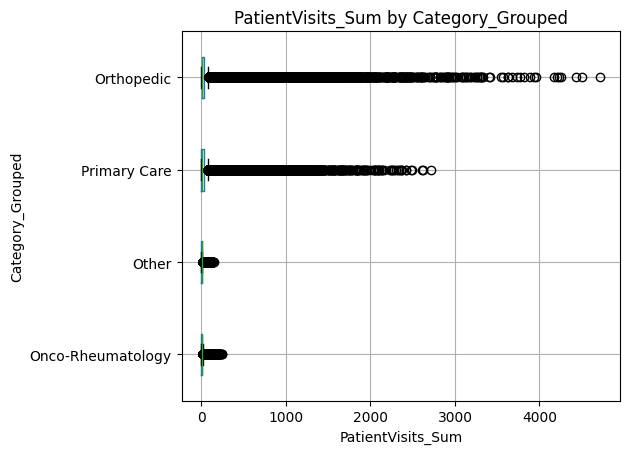


ANOVA for Category_Grouped

                           sum_sq        df            F  PR(>F)
C(Category_Grouped)  2.219718e+08       3.0  2005.250627     0.0
Residual             3.992189e+09  108194.0          NaN     NaN


<Figure size 800x400 with 0 Axes>

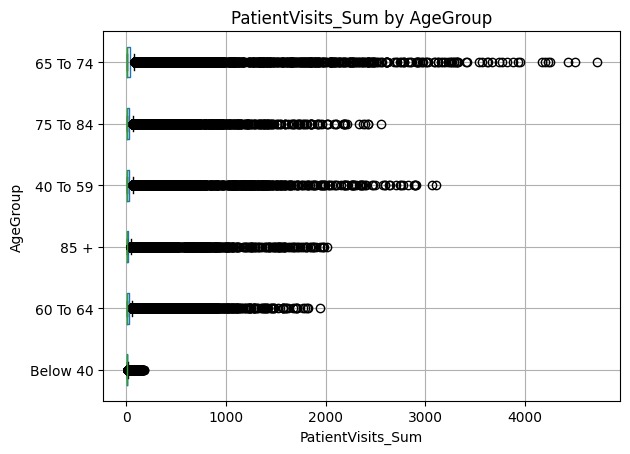


ANOVA for AgeGroup

                   sum_sq        df            F  PR(>F)
C(AgeGroup)  2.048351e+08       5.0  1096.758454     0.0
Residual     4.041276e+09  108192.0          NaN     NaN


<Figure size 800x400 with 0 Axes>

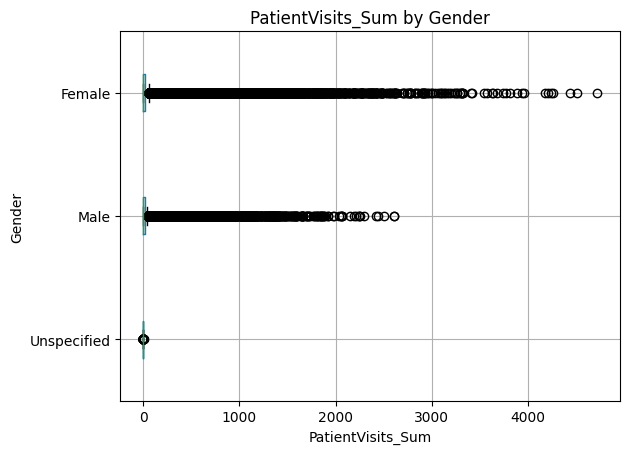


ANOVA for Gender

                 sum_sq        df            F  PR(>F)
C(Gender)  2.932162e+08       2.0  3899.751597     0.0
Residual   4.067506e+09  108195.0          NaN     NaN


<Figure size 800x400 with 0 Axes>

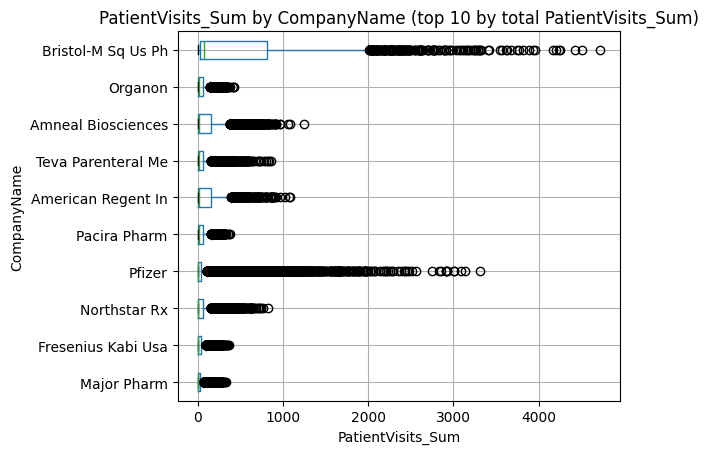


ANOVA for CompanyName (top-k subset)

                      sum_sq       df           F  PR(>F)
C(CompanyName)  3.145211e+08      9.0  553.658579     0.0
Residual        3.174166e+09  50288.0         NaN     NaN


<Figure size 800x400 with 0 Axes>

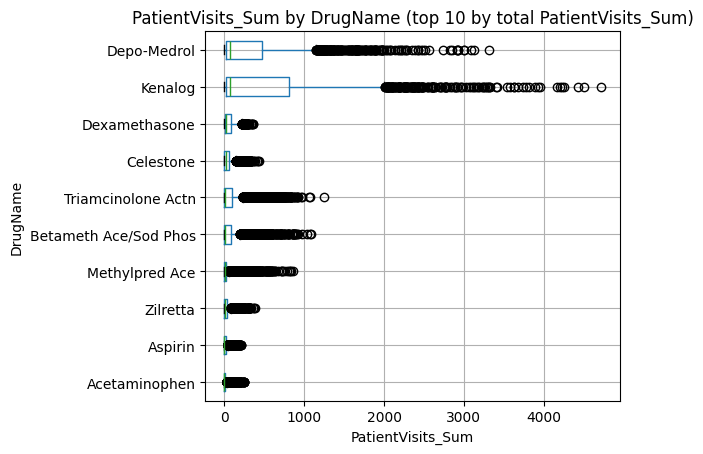


ANOVA for DrugName (top-k subset)

                   sum_sq       df            F  PR(>F)
C(DrugName)  4.262326e+08      9.0  1009.872595     0.0
Residual     2.989116e+09  63739.0          NaN     NaN


<Figure size 800x400 with 0 Axes>

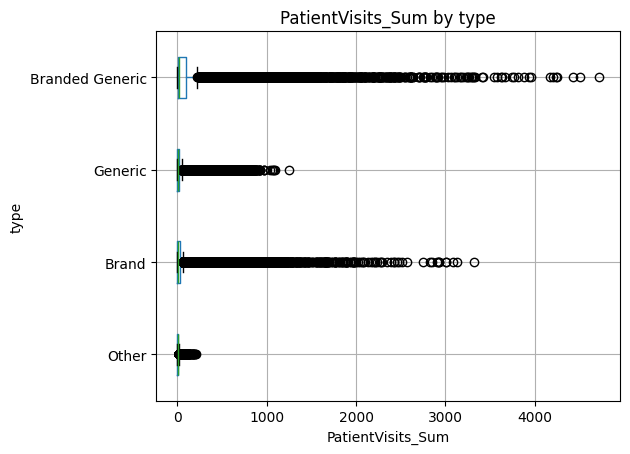


ANOVA for type

                sum_sq        df            F  PR(>F)
C(type)   3.020949e+08       3.0  2888.110826     0.0
Residual  3.772346e+09  108194.0          NaN     NaN


In [31]:

TOP_K = 10

for col in categorical_cols:
    d = df[[col, TARGET]].dropna()
    if d[col].nunique() < 2:
        continue
    used_subset = False
    if d[col].nunique() > TOP_K:
        top_levels = (
            d.groupby(col)[TARGET]
              .sum()
              .sort_values(ascending=False)
              .head(TOP_K)
              .index
        )
        d = d[d[col].isin(top_levels)].copy()
        used_subset = True

    order = d.groupby(col)[TARGET].median().sort_values().index
    d[col] = pd.Categorical(d[col], categories=order, ordered=True)

    plt.figure(figsize=(8, 4))
    d.boxplot(column=TARGET, by=col, vert=False)
    ttl = f"{TARGET} by {col}"
    if used_subset:
        ttl += f" (top {TOP_K} by total {TARGET})"
    plt.title(ttl)
    plt.suptitle("")
    plt.xlabel(TARGET)
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    try:
        model = smf.ols(f"{TARGET} ~ C({col})", data=d).fit(cov_type="HC3")
        a = anova_lm(model, typ=2)
        print(f"\nANOVA for {col}" + (" (top-k subset)" if used_subset else "") + "\n")
        print(a)

    except Exception as e:
        print(f"ANOVA failed for {col}: {e}\n")

Category_Grouped -> PatientVisits_Sum

Boxplot defining that Primary Care and Orthopedic have the Higher Medians and massive outliers and very wide distribution other and onco have low median values and much tighter distribution. Anova tells that some categories deals with more patienrs while others handle fewer and the category strongly influences patient volumes.


AgeGroup -> PatientVisits_Sum

Age group has major impact on total patient visits.


Gender -> Patientvisits
Female and Male have large similar distributions and unspecified has almost no volume gender still influences visit counts, but the effect is smaller compared to age or category.

CompanyName->PatientVisits_Sum
High-Cardinality categorical feature, some drug manufactures dominate the patient volume. CompanyName is very strong differentaitor for patient volume.

DrugName->patientvisits
Less used drugs ahve tight clusters
srugname is also highly influential.

Type->patientvisits
Branded Generics and Brands show:
Very high outliers
Higher medians
Generic and Other:
Lower median visits
Tighter spread

ComapnyName: Some companies are associated with extremely high patient visit counts. CompanyName is a strong explanatory variable for patient visit counts.

DrugName: Different drugs have drastically different visit distributions.The variability across drugs is even stronger than across companies.
DrugName has more explanatory power than CompanyName

the type of drug strongly affects total visit counts.
as all anove p-values are 0 Category, AgeGroup, Gender, CompanyName, DrugName, and type all show significant differences in how many visits they receive.”



CompanyName and DrugName requires target encoding, Frequency Encoding and Catboost internal handling

Anova tells that categories are meaningful and supports Segmentation analysis
Stratified modeling
Interaction modeling later (Category × AgeGroup)

In [32]:
for c1, c2 in combinations(categorical_cols, 2):
    d = df[[c1, c2]].dropna()
    if d[c1].nunique() < 2 or d[c2].nunique() < 2:
        continue

    ct = pd.crosstab(d[c1], d[c2])
    chi2, p, dof, exp = stats.chi2_contingency(ct)

    print(f"{c1} ↔ {c2} | p-value={p:.4f}, dof={dof}")
    if p < 0.05:
        print("  → Significant association")
    print()

Category_Grouped ↔ AgeGroup | p-value=0.0000, dof=15
  → Significant association

Category_Grouped ↔ Gender | p-value=0.0000, dof=6
  → Significant association

Category_Grouped ↔ CompanyName | p-value=0.0000, dof=495
  → Significant association

Category_Grouped ↔ DrugName | p-value=0.0000, dof=432
  → Significant association

Category_Grouped ↔ type | p-value=0.0000, dof=9
  → Significant association

AgeGroup ↔ Gender | p-value=0.0000, dof=10
  → Significant association

AgeGroup ↔ CompanyName | p-value=0.0000, dof=825
  → Significant association

AgeGroup ↔ DrugName | p-value=0.0000, dof=720
  → Significant association

AgeGroup ↔ type | p-value=0.0000, dof=15
  → Significant association

Gender ↔ CompanyName | p-value=0.0000, dof=330
  → Significant association

Gender ↔ DrugName | p-value=0.0000, dof=288
  → Significant association

Gender ↔ type | p-value=0.0000, dof=6
  → Significant association

CompanyName ↔ DrugName | p-value=0.0000, dof=23760
  → Significant association

Co

1. All categorical features are not independent. They are strongly correlated or associated.
2. Many category features carry overlapping signal
3. There is high multi-collinearity risk espicially when using Logistic/Linear regression, GLM , ANOVA
4. Time-based models like CatBoost,XGBoost and RF will handle this multicollinearity naturally.
5. For regression models, we have to check VIF(Variance Inflation Factor) - how much a predictor (independent variable) is correlated with other predictors. Also, Many categorical features may need dimensionality reduction, target encoding and grouping low-frequency categories.

,Feature1,Feature2,CramersV
17,CompanyName,type,0.926292
20,DrugName,type,0.916136
16,CompanyName,DrugName,0.557077
3,Category_Grouped,DrugName,0.221093
2,Category_Grouped,CompanyName,0.213368
4,Category_Grouped,type,0.104594
19,DrugName,Gender,0.104386
15,CompanyName,Gender,0.100981
10,AgeGroup,DrugName,0.086949
9,AgeGroup,CompanyName,0.079799


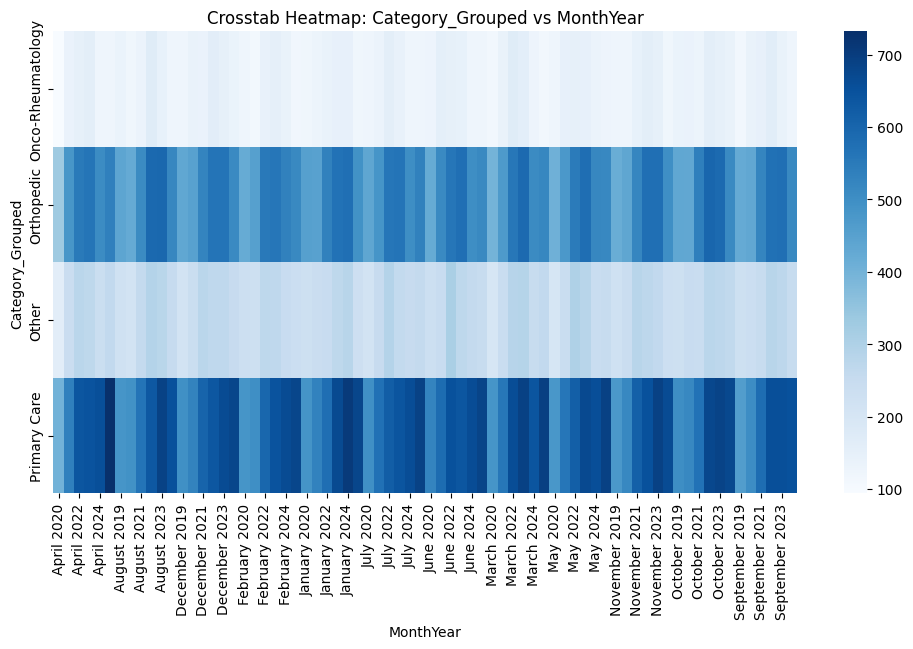

In [33]:
def cramers_v(confusion_matrix):
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))

import scipy.stats as ss

cat_pairs = []
for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 >= c2:
            continue
        table = pd.crosstab(df[c1], df[c2])
        v = cramers_v(table.values)
        cat_pairs.append([c1, c2, v])

cv_df = pd.DataFrame(cat_pairs, columns=["Feature1","Feature2","CramersV"])
display(cv_df.sort_values("CramersV", ascending=False).head(20))


plt.figure(figsize=(12,6))
sns.heatmap(
    pd.crosstab(df[cat_cols[0]], df[cat_cols[1]]),
    cmap="Blues"
)
plt.title(f"Crosstab Heatmap: {cat_cols[0]} vs {cat_cols[1]}")
plt.show()

Category cardinalities:
{'Category_Grouped': 4, 'MonthYear': 72, 'AgeGroup': 6, 'Gender': 3, 'type': 4, 'CompanyName': 166, 'DrugName': 145}

Skipping heatmap for Category_Grouped vs MonthYear (too many categories)

Plotting heatmap: Category_Grouped vs Gender


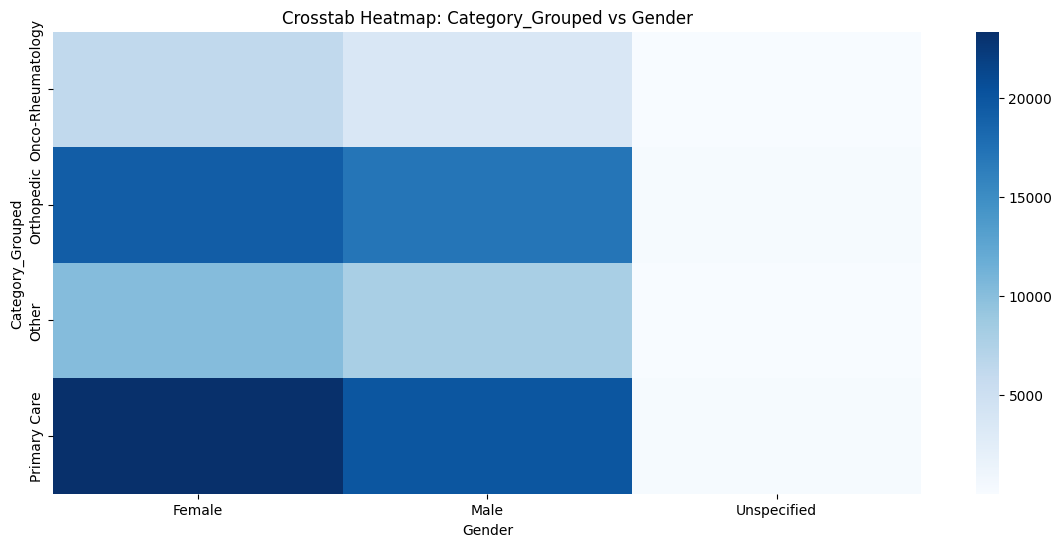


Plotting heatmap: Category_Grouped vs type


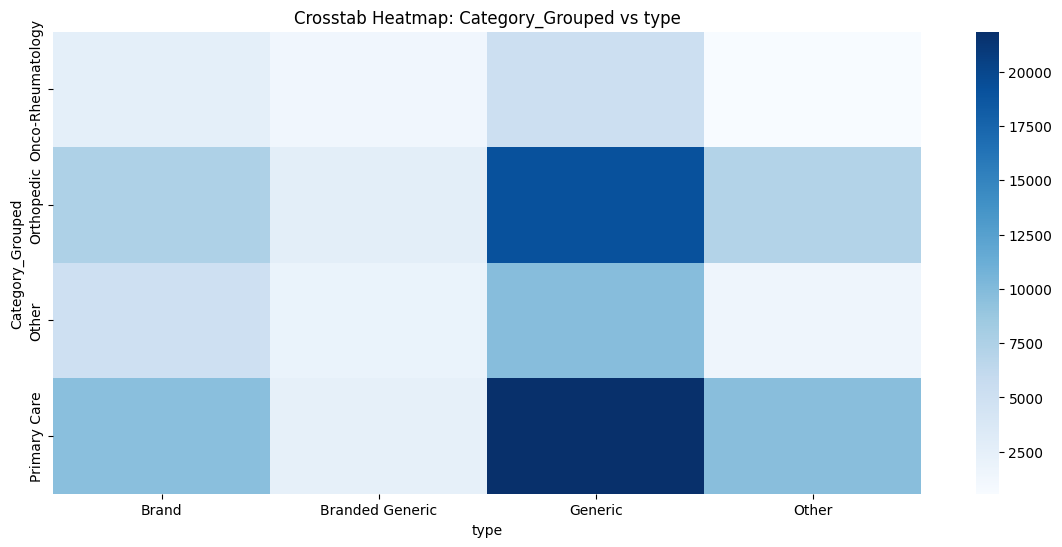


Skipping heatmap for Category_Grouped vs CompanyName (too many categories)

Skipping heatmap for Category_Grouped vs DrugName (too many categories)

Skipping heatmap for MonthYear vs type (too many categories)

Plotting heatmap: AgeGroup vs Category_Grouped


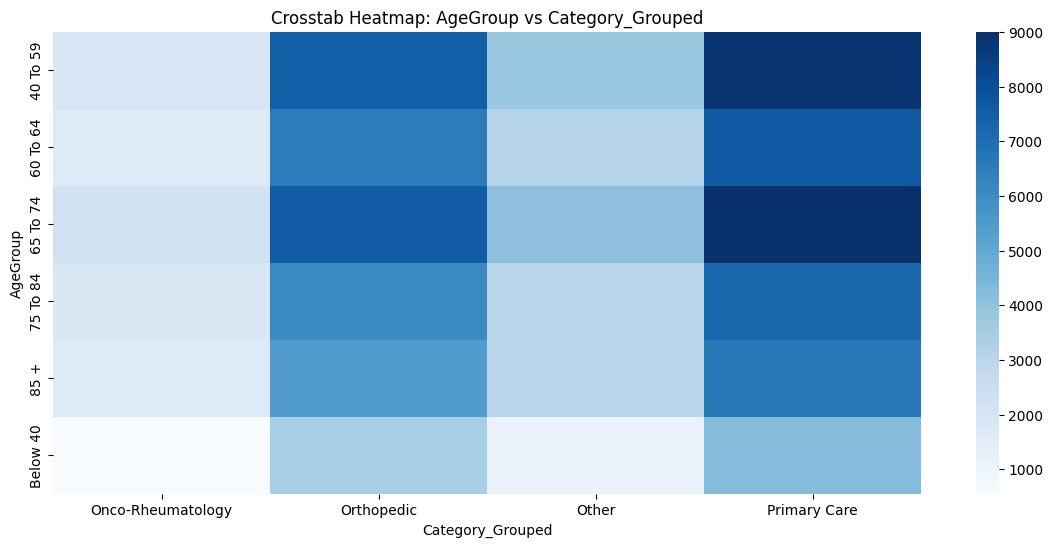


Skipping heatmap for AgeGroup vs MonthYear (too many categories)

Plotting heatmap: AgeGroup vs Gender


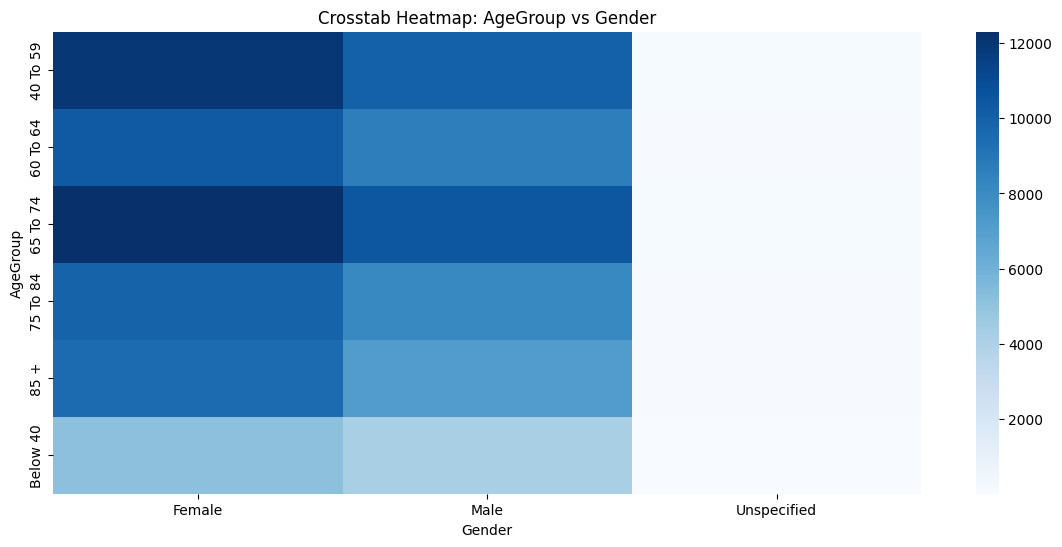


Plotting heatmap: AgeGroup vs type


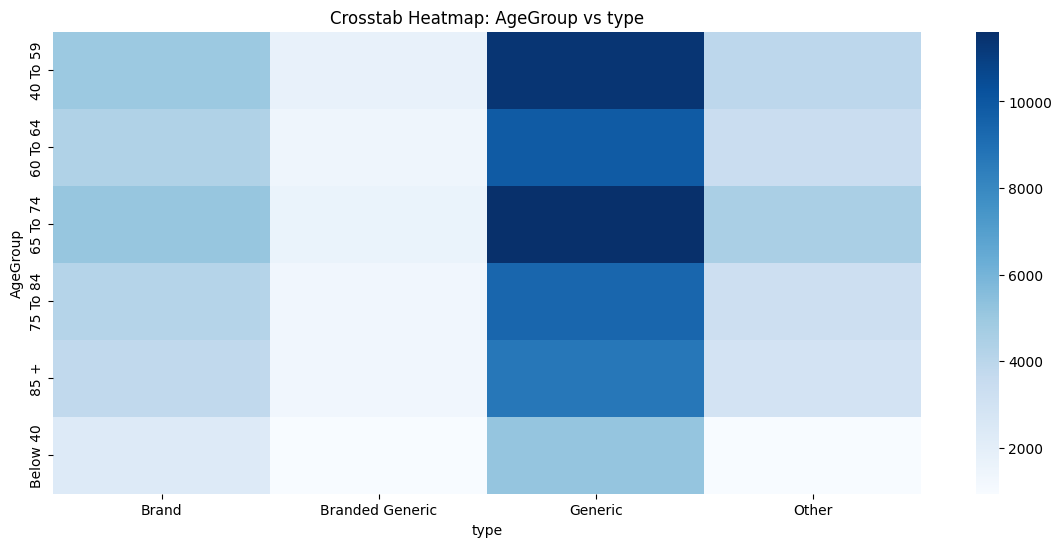


Skipping heatmap for AgeGroup vs CompanyName (too many categories)

Skipping heatmap for AgeGroup vs DrugName (too many categories)

Skipping heatmap for Gender vs MonthYear (too many categories)

Plotting heatmap: Gender vs type


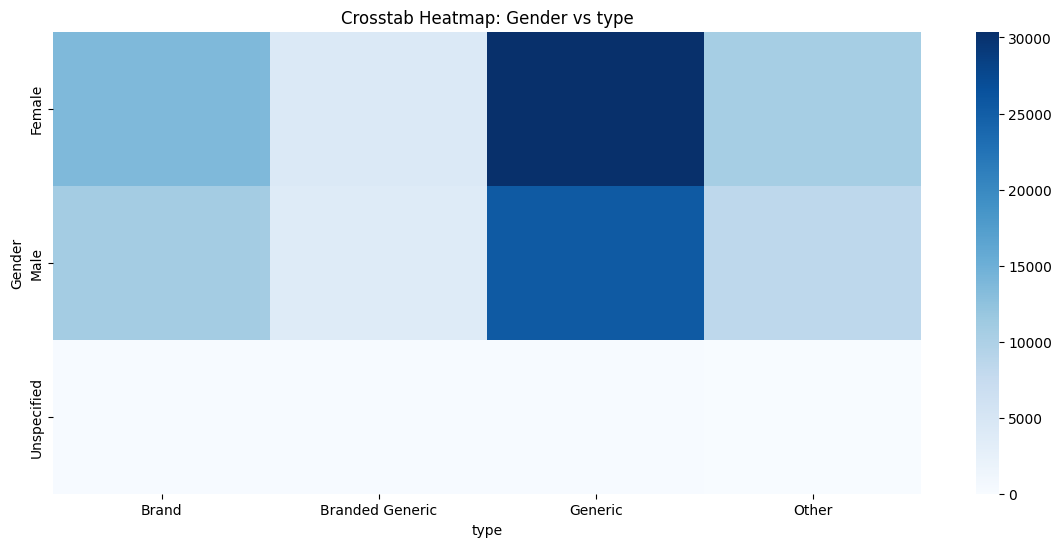


Skipping heatmap for CompanyName vs MonthYear (too many categories)

Skipping heatmap for CompanyName vs Gender (too many categories)

Skipping heatmap for CompanyName vs type (too many categories)

Skipping heatmap for CompanyName vs DrugName (too many categories)

Skipping heatmap for DrugName vs MonthYear (too many categories)

Skipping heatmap for DrugName vs Gender (too many categories)

Skipping heatmap for DrugName vs type (too many categories)


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cat_cols = ['Category_Grouped', 'MonthYear', 'AgeGroup', 'Gender', 'type',
            'CompanyName', 'DrugName']
cardinality = {col: df[col].nunique() for col in cat_cols}

print("Category cardinalities:")
print(cardinality)
MAX_CATS = 20

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 >= c2:
            continue

        if df[c1].nunique() > MAX_CATS or df[c2].nunique() > MAX_CATS:
            print(f"\nSkipping heatmap for {c1} vs {c2} (too many categories)")
            continue

        print(f"\nPlotting heatmap: {c1} vs {c2}")

        ct = pd.crosstab(df[c1], df[c2])

        plt.figure(figsize=(14,6))
        sns.heatmap(ct, cmap="Blues")
        plt.title(f"Crosstab Heatmap: {c1} vs {c2}")
        plt.show()
